# Data pre-processing

In [45]:
%load_ext autoreload
%autoreload 2

import io
import base64
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output
from matplotlib_venn import venn2
from matplotlib.figure import Figure as plt_Figure
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from data_viz import (step_plot_distribution,
                      pie_chart_multilabels_proportion,
                      pie_chart_simple,
                      bar_plot_distribution_with_floating_text,
                      bar_plot_habitats_distribution_VS_syntaxons,
                      stack_bars_habitats,
                      upset_plot_habitats_per_soft_labeling,
                      jaccard_sim_habitat_soft_multilabeling,
                      stacked_bars_habitat_distribution,
                      bar_plot_habitats_soft_multilabel,
                      plot_stacked_bar_multilabel_stratify)
from stats import get_basic_stats
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
def fig_to_img(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    data = base64.b64encode(buf.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="margin-right:20px;">'

def file_to_img(path):
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="margin-right:20px;">'

def display_plots_side_by_side(figs):
    html = '<div style="display:flex; align-items:flex-start;">'
    for fig in figs:
        if isinstance(fig, plt_Figure):
            html += fig_to_img(fig)
        elif isinstance(fig, str):
            html += file_to_img(fig)
    html += '\n</div>'
    display(HTML(html))

## FloraVeg habitat labels

The FloraVeg habitats dataset is a collection of ground-level images associated with a EUNIS lvl3 habitat label. Some of the images are also geo-tagged with WGS4326 lon/lat values.

There are 3 CSV files:
- `metadata.csv`: contains the image samples and metadata associated
- `metadata_labels.csv`: contains the EUNIS habitat labels written as plain text description, with a merge key column named "syntaxons" which makes possible to associate samples with their label(s)
- `habitats_code.csv`: a translation table between plain text EUNIS habitats description and their code name _(e.g.: Arctic littoral biogenic habitats $\rightarrow$ MA21)_

⚠️ <span style="color:red"> **IMPORTANT: the merge key "syntaxons" in `metadata_labels.csv` is a NON UNIQUE matching key, meaning ONE sample syntaxon can be matched with SEVERAL EUNIS habitat labels** </span>

In [47]:
df_occurrences = pd.read_csv('metadata.csv')
df_labels = pd.read_csv('metadata_labels.csv')
df_code = pd.read_csv('habitats_code.csv').iloc[1:]  # Skipping 1st row because it contains a secondary header
df_code['code'] = df_code['code'].apply(lambda x: x.strip())
print(f'\033[1m● \x1B[4mOccurences\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences.columns.tolist()}')
display(df_occurrences.head(2))
print(f'\033[1m● \x1B[4mLabels\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_labels.shape} \n \x1B[4mColumns\x1B[0m: {df_labels.columns.tolist()}')
display(df_labels.head(2))
print(f'\033[1m● \x1B[4mLabels conversion table\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_code.shape} \n \x1B[4mColumns\x1B[0m: {df_code.columns.tolist()}')
display(df_code.head(2))

● Occurences: 
 > Shape: (5130, 12) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN
1,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,NaN,NaN


● Labels: 
 Shape: (1362, 6) 
 Columns: ['habitats', 'syntaxons', 'code', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description
1,"Atlantic, Baltic and Arctic sand beach",Salsolo-Minuartion peploidis,>,NaN,<,the type left of the qualifier is defined as a...


● Labels conversion table: 
 Shape: (396, 6) 
 Columns: ['code', 'name', 'Level_1', 'Level_2', 'Level_3', 'Level_4']


,code,name,Level_1,Level_2,Level_3,Level_4
1,MA,Marine habitats,True,False,False,False
2,N,Coastal habitats,True,False,False,False


In [48]:
print(f'\033[1m● \x1B[4mOccurences\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences.columns.tolist()}')
display(df_occurrences.head(1))
print(f'\033[1m● \x1B[4mLabels\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_labels.shape} \n \x1B[4mColumns\x1B[0m: {df_labels.columns.tolist()}')
display(df_labels.head(1))
print(f'\033[1m● \x1B[4mLabels conversion table\x1B[0m\033[0m: \n \x1B[4mShape\x1B[0m: {df_code.shape} \n \x1B[4mColumns\x1B[0m: {df_code.columns.tolist()}')
display(df_code.head(2))

df_occurrences_gps_only = df_occurrences.dropna(subset=["lon", "lat"])
df_occurrences_gps_only.to_csv('metadata_gps_only.csv', index=False)
print(f'GPS-only occurrences: {df_occurrences_gps_only.shape}')

● Occurences: 
 > Shape: (5130, 12) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN


● Labels: 
 Shape: (1362, 6) 
 Columns: ['habitats', 'syntaxons', 'code', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']


,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description


● Labels conversion table: 
 Shape: (396, 6) 
 Columns: ['code', 'name', 'Level_1', 'Level_2', 'Level_3', 'Level_4']


,code,name,Level_1,Level_2,Level_3,Level_4
1,MA,Marine habitats,True,False,False,False
2,N,Coastal habitats,True,False,False,False


GPS-only occurrences: (3527, 12)


## Coverage
The dataset is mainly focused on Europe, but some points land outside.<br>
_E.g.: point in Alask with lon/lat = (-149,37454166667, 68,452866666667) representing Dryadion integrifoliae_


<div style="display: flex; gap: 10px; align-items: center;">
  <img src="resources/FLoraVeg_Alaska_outlier.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
  <img src="resources/FLoraVeg_Europe_extent_(small).png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
</div>

### A few statistics
There are **5 130 occurrences** with each 1 image and 1 FloraVeg ID.\
Amongst them, **3 527 (68.75%)** are geo-tagged and scattered over **2 272 unique plots**, while 1 603 (31.25%) are NOT geo-tagged.

The dataset has **248 habitats** registered.\
The data (occurrences), and the labels (EUNIS-lvl3 habitats and EUNIS-lvl3 habitat codes) are given in separate files and can be matched using a correspondances key `syntaxons`.\
However, columns `syntaxons` and `habitats` do not match 1-to-1. Each habitat matches 1 to 32 different syntaxons (also, in the labels file, some habitat-syntaxon pairs appear multiple times, e.g. habitat n°1, n°69...).

---

In [49]:
n_unique_fids, n_unique_labels, n_occu_valid_gps, n_occu_invalid_gps, n_occurrences, n_plots, n_unique_habitats = get_basic_stats(df_occurrences, df_labels, return_stats=True)

Nb occurrences (illustrated): 5130
Nb unique FloraVeg IDs: 5130
Occurrences: 3527 (68.75%) with GPS | 1603 (31.25%) without
Nb of unique plots with valid GPS: 2273

Nb unique habitats: 248
Nb unique syntaxons (from occurrences file): 567
Nb unique syntaxons (from labels file): 1088



,habitats,syntaxons,code,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,<>,NaN,code,description
1,"Atlantic, Baltic and Arctic sand beach",Salsolo-Minuartion peploidis,>,NaN,<,the type left of the qualifier is defined as a...
2,"Atlantic, Baltic and Arctic sand beach",Agropyro-Rumicion,<>,NaN,>,the type left of the qualifier is defined as a...



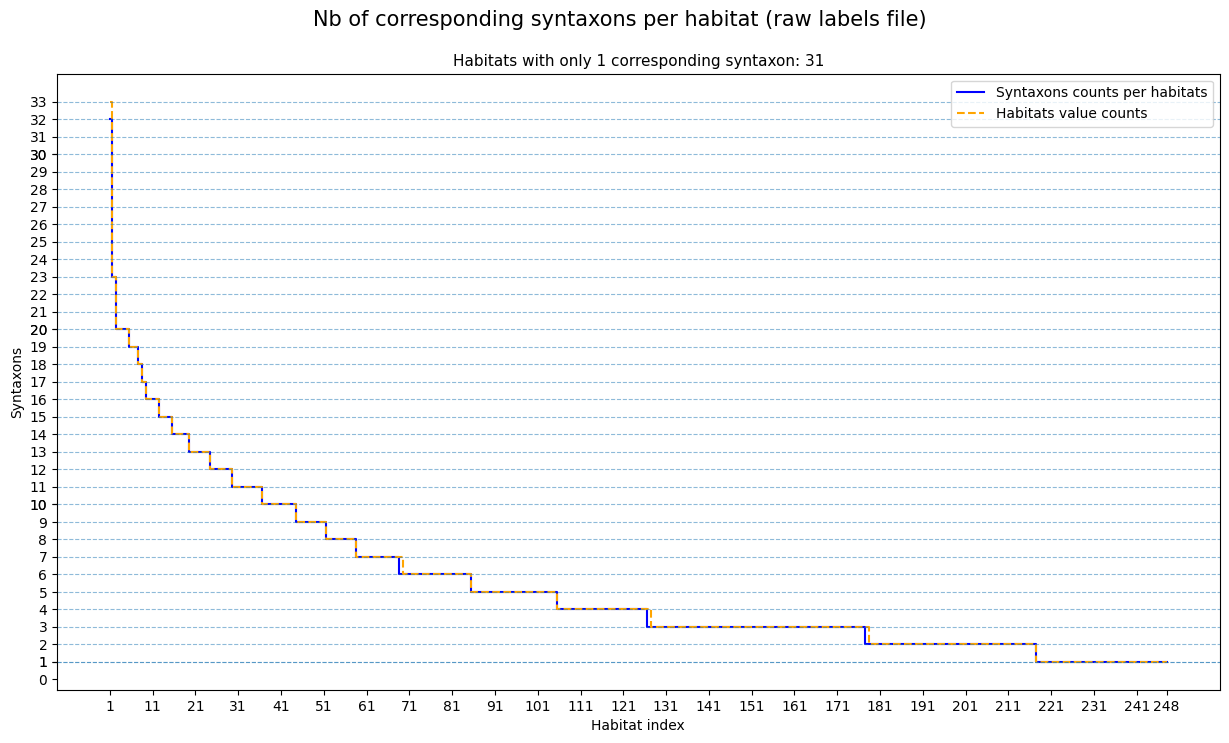
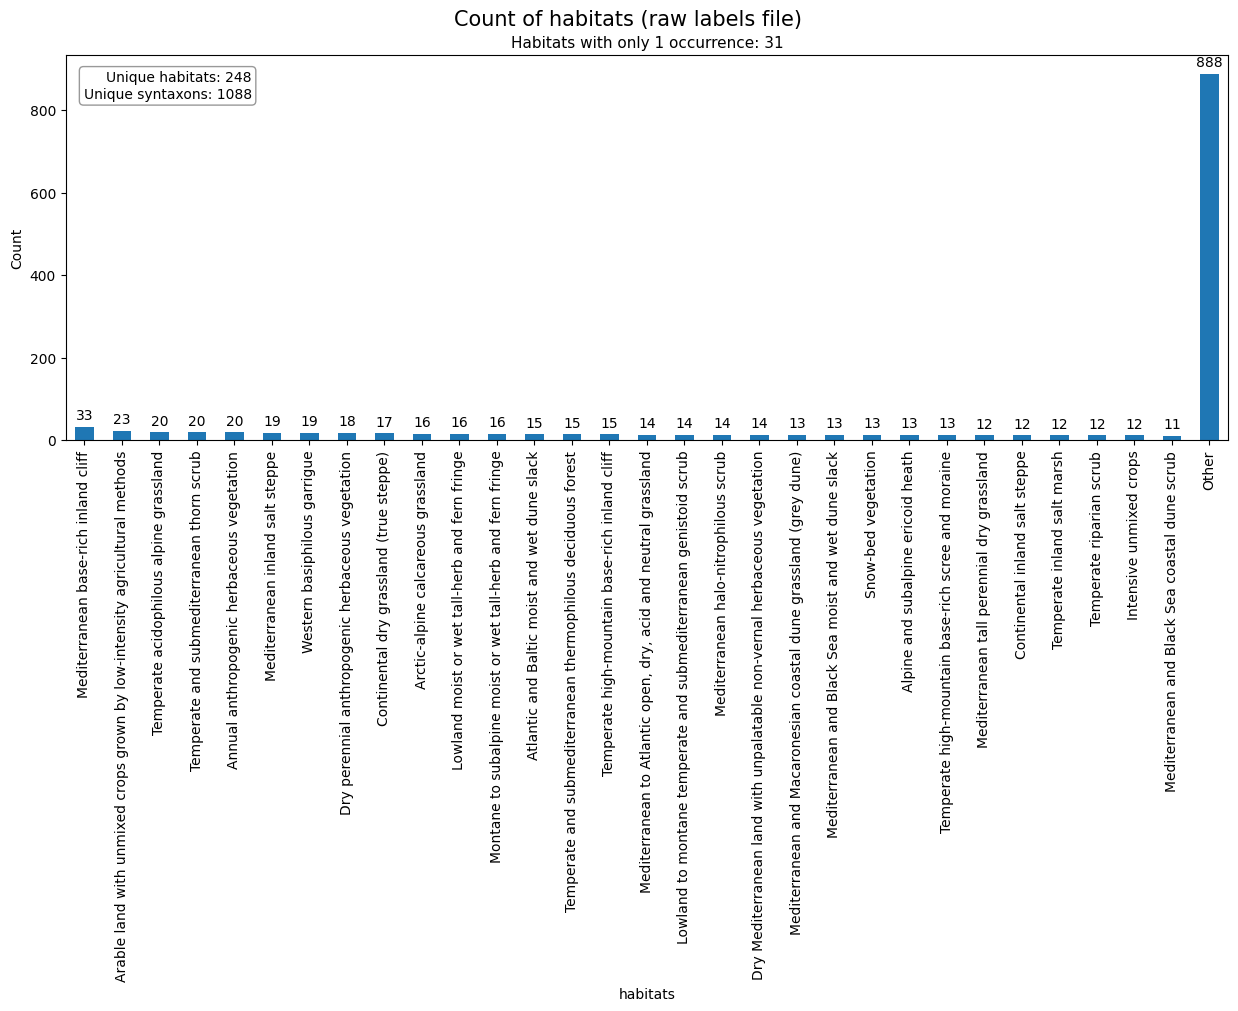

In [50]:
fig1, habitat_distrib = bar_plot_habitats_distribution_VS_syntaxons(df_labels, top_k=248, title='Nb of corresponding syntaxons per habitat (raw labels file)', plot_width=15, fp_out='resources/Habitats_VS_Syntaxons_dstribution(raw_labels).png', plot=False)
fig2, habitat_counts = bar_plot_distribution_with_floating_text(df_labels, 'habitats', top_k=30, title='Count of habitats (raw labels file)', plot_width=15, fp_out='resources/Count_of_habitats_(raw_labels).png', plot=False)
display_plots_side_by_side([fig1, fig2])

### Merging occurrences and labels

After merging files, **habitats match 1 to 326 occurrences**. Conversely, **occurrences match 1 to 5 labels**.

**86.69% (215) habitats** match at least 1 occurence, of which **8 (3.72%) habitats** match only **one occurrence**.\
**65.68% (3 179) occurrences** match only **one habitat**.

Outside of the scope of this project, FloraVeg registers 396 habitats (any level), of which 336 are of level-3. However, only 215 of those (~64%) are illustrated. And only 248 can be linked to samples because that's how many syntaxons we have to merge tables.

In [51]:
df_code['code'].nunique()

396

In [52]:
df_code_renamed = df_code.rename(columns={'code': 'habitats_code', 'name': 'habitats'}).iloc[1:]  # Skipping 1st row because it is a secondary header
df_labels_renamed = df_labels[['habitats', 'syntaxons']]
df_labels_with_code = pd.merge(df_labels_renamed, df_code_renamed, left_on='habitats', right_on='habitats')

df_occurrences_merged = pd.merge(df_occurrences, df_labels_with_code, left_on='syntaxon_floraveg', right_on='syntaxons')
df_occurrences_merged.drop(columns=['Level_1', 'Level_2', 'Level_3', 'Level_4'])

print(f'\033[1m● \x1B[4mLabels with code\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_labels_with_code.shape} \n > \x1B[4mColumns\x1B[0m: {df_labels_with_code.columns.tolist()}')
display(df_labels_with_code.head(1))

print(f'\033[1m● \x1B[4mOccurrences with labels & code\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences_merged.shape} \n > \x1B[4mColumns\x1B[0m: {df_occurrences_merged.columns.tolist()}')
display(df_occurrences_merged.head(1))

df_occurrences_merged.to_csv('metadata_labels_merged.csv', index=False)
df_occurrences_merged_gps_only = df_occurrences_merged.dropna(subset=["lon", "lat"])
df_occurrences_merged_gps_only.to_csv('metadata_labels_merged_gps_only.csv', index=False)
print(f"\033[1m● \x1B[4mOccurrences with labels & code (GPS only)\x1B[0m\033[0m: \n > \x1B[4mShape\x1B[0m: {df_occurrences_merged_gps_only.shape} \n > \x1B[4mNb unique sites\x1B[0m: {df_occurrences_merged_gps_only['id_floraveg'].nunique()}")

● Labels with code: 
 > Shape: (1362, 7) 
 > Columns: ['habitats', 'syntaxons', 'habitats_code', 'Level_1', 'Level_2', 'Level_3', 'Level_4']


,habitats,syntaxons,habitats_code,Level_1,Level_2,Level_3,Level_4
0,"Atlantic, Baltic and Arctic sand beach",Atriplicion littoralis,N11,False,False,True,False


● Occurrences with labels & code: 
 > Shape: (7948, 19) 
 > Columns: ['filename_photos', 'syntaxon_floraveg', 'author_floraveg', 'country', 'id_floraveg', 'locality', 'author_name', 'domin_taxa', 'association', 'coords_precision', 'lat', 'lon', 'habitats', 'syntaxons', 'habitats_code', 'Level_1', 'Level_2', 'Level_3', 'Level_4']


,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code,Level_1,Level_2,Level_3,Level_4
0,Arunco_vulgaris-Lunarietum_redivivae2.jpg,Impatienti noli-tangere-Stachyion sylvaticae,Görs ex Mucina 1993,Czech Republic,12486,Ještědský hřbet (distr. Liberec),Petr Petřík,NaN,NaN,NaN,NaN,NaN,Lowland moist or wet tall-herb and fern fringe,Impatienti noli-tangere-Stachyion sylvaticae,R55,False,False,True,False


● Occurrences with labels & code (GPS only): 
 > Shape: (5504, 19) 
 > Nb unique sites: 3271


In [53]:
df_occurrences_merged.sample()

,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code,Level_1,Level_2,Level_3,Level_4
4618,Centaureo-Bromion_fibrosi_(eu)1.jpg,Centaureo-Bromion fibrosi,Blečić et al. 1969,Kosovo,14632,"Pashallarë, Malet e Sharrit, alpine serpentine...",Naim Berisha,"Bornmuellera dieckii, Poa badensis, Sedum albu...",Sedo-Bornmullerietum dieckii Blecić,NaN,42.24375,20.907324,Heavy-metal dry grassland of the Balkans,Centaureo-Bromion fibrosi,R17,False,False,True,False


In [54]:
def extract_eunis_lvl(code, lvl):
    if code.startswith('MA'):
        return code[:lvl+1] if lvl+1 <= len(code) else ''
    else:
        return code[:lvl] if lvl <= len(code) else ''

In [55]:
# Old method
# # Encoding labels. This step is done here to ensure stability of labels encoding throughout the training process
# re_pattern_lvl3 = re.compile(r'^(?:MA2[A-Za-z0-9]{2,}|(?!MA2)[A-Za-z0-9]{3,})$')

# # Encoding all EUNIS labels
# le = LabelEncoder()
# le.fit(df_code['code'].values)
# df_code['code_ID'] = le.transform(df_code['code'].values)
# df_code['Level_3'] = [bool(re_pattern_lvl3.match(x)) for x in df_code['code']]
# assert df_code['code'].nunique() == df_code['code_ID'].nunique()
# df_code.to_csv('habitats_code_encoded.csv', index=False)
# print(df_code['Level_3'].sum())

# # Encoding only level-3 EUNIS labels illustrated in our dataset
# habitats_code_lvl_3 = [x for x in df_code['code'] if bool(re_pattern_lvl3.match(x))]
# le_lvl3 = LabelEncoder()
# le_lvl3.fit(df_occurrences_merged['habitats_code'].unique())
# df_occurrences_merged['habitats_code_ID'] = le_lvl3.transform(df_occurrences_merged['habitats_code'])
# assert len(habitats_code_lvl_3) == df_code['Level_3'].sum()
# assert df_occurrences_merged['habitats_code_ID'].max() == df_occurrences_merged['habitats_code'].nunique()-1
# df_occurrences_merged.to_csv('metadata_labels_merged_encoded.csv', index=False)

# df_occurrences_merged_gps_only = df_occurrences_merged.dropna(subset=["lon", "lat"])
# df_occurrences_merged_gps_only.to_csv('metadata_labels_merged_gps_only_encoded.csv', index=False)

# print(f'FloraVeg registers a total of {len(df_code)} possible habitats. Of which, {len(habitats_code_lvl_3)} are of level-3. (yes it\'s more than what\'s being referenced online, ~260, but it\'s the data FloraVeg shared with us)')


In [56]:
#### Encoding labels. This step is done here to ensure stability of labels encoding throughout the training process
old_re_pattern_lvl3_4 = re.compile(r'^(?:MA2[A-Za-z0-9]{2,}|(?!MA2)[A-Za-z0-9]{3,})$')
re_pattern_lvl1 = re.compile(r'^(?:MA.{0}|(?!MA).{1})$')  # order of [A-Za-z]{2} and [A-Za-z] is important because the 1st match takes priority
re_pattern_lvl2 = re.compile(r'^(?:MA.{1}|(?!MA).{2})$')
re_pattern_lvl3 = re.compile(r'^(?:MA.{2}|(?!MA).{3})$')
re_pattern_lvl4 = re.compile(r'^(?:MA.{3}|(?!MA).{4})$')

# Encoding all EUNIS labels
le = LabelEncoder()
le.fit(df_code['code'].values)
df_code['code_ID'] = le.transform(df_code['code'].values)
df_code.to_csv('habitats_code_encoded.csv', index=False)

# Extend occurrences with all EUNIS lvl codes
df_occurrences_merged['habitats_code_lvl1'] = df_occurrences_merged['habitats_code'].apply(lambda x: extract_eunis_lvl(x, lvl=1))
df_occurrences_merged['habitats_code_lvl2'] = df_occurrences_merged['habitats_code'].apply(lambda x: extract_eunis_lvl(x, lvl=2))
df_occurrences_merged['habitats_code_lvl3'] = df_occurrences_merged['habitats_code'].apply(lambda x: extract_eunis_lvl(x, lvl=3))
df_occurrences_merged['habitats_code_lvl4'] = df_occurrences_merged['habitats_code'].apply(lambda x: extract_eunis_lvl(x, lvl=4))

# Encoding EUNIS labels for each level, illustrated in our dataset
old_lvl3_4 = [bool(old_re_pattern_lvl3_4.match(x)) for x in df_code['code']]  # length: 336 (330/330 from lvl3, 6/11 from lvl4)
habitats_code_lvl_1 = [x for x in df_code['code'] if bool(re_pattern_lvl1.match(x))]
habitats_code_lvl_2 = [x for x in df_code['code'] if bool(re_pattern_lvl2.match(x))]
habitats_code_lvl_3 = [x for x in df_code['code'] if bool(re_pattern_lvl3.match(x))]
habitats_code_lvl_4 = [x for x in df_code['code'] if bool(re_pattern_lvl4.match(x))]
le_lvl1, le_lvl2, le_lvl3, le_lvl4, le_lvl3_4 = LabelEncoder(), LabelEncoder(), LabelEncoder(), LabelEncoder(), LabelEncoder()
le_lvl1.fit(df_occurrences_merged['habitats_code_lvl1'].unique())
le_lvl2.fit(df_occurrences_merged['habitats_code_lvl2'].unique())
le_lvl3.fit(df_occurrences_merged['habitats_code_lvl3'].unique())
le_lvl4.fit(df_occurrences_merged['habitats_code_lvl4'].unique())
le_lvl3_4.fit(df_occurrences_merged['habitats_code'].unique())
df_occurrences_merged['habitats_code_ID_lvl1'] = le_lvl1.transform(df_occurrences_merged['habitats_code_lvl1'])
df_occurrences_merged['habitats_code_ID_lvl2'] = le_lvl2.transform(df_occurrences_merged['habitats_code_lvl2'])
df_occurrences_merged['habitats_code_ID_lvl3'] = le_lvl3.transform(df_occurrences_merged['habitats_code_lvl3'])
df_occurrences_merged['habitats_code_ID_lvl4'] = le_lvl4.transform(df_occurrences_merged['habitats_code_lvl4'])
df_occurrences_merged['habitats_code_ID'] = le_lvl3_4.transform(df_occurrences_merged['habitats_code'])

assert len(habitats_code_lvl_1) == df_code['Level_1'].sum()
assert len(habitats_code_lvl_2) == df_code['Level_2'].sum()
assert len(habitats_code_lvl_3) == df_code['Level_3'].sum()
assert len(habitats_code_lvl_4) == df_code['Level_4'].sum()
assert df_occurrences_merged['habitats_code_ID'].max() == df_occurrences_merged['habitats_code'].nunique()-1
assert df_occurrences_merged['habitats_code_ID_lvl1'].max() == df_occurrences_merged['habitats_code_lvl1'].nunique()-1
assert df_occurrences_merged['habitats_code_ID_lvl2'].max() == df_occurrences_merged['habitats_code_lvl2'].nunique()-1
assert df_occurrences_merged['habitats_code_ID_lvl3'].max() == df_occurrences_merged['habitats_code_lvl3'].nunique()-1
assert df_occurrences_merged['habitats_code_ID_lvl4'].max() == df_occurrences_merged['habitats_code_lvl4'].nunique()-1
df_occurrences_merged.to_csv('metadata_labels_merged_encoded.csv', index=False)

df_occurrences_merged_gps_only = df_occurrences_merged.dropna(subset=["lon", "lat"])
df_occurrences_merged_gps_only.to_csv('metadata_labels_merged_gps_only_encoded.csv', index=False)

print(f'FloraVeg registers a total of {len(df_code)} possible habitats. Of which, {len(habitats_code_lvl_3)} are of level-3. (yes it\'s more than what\'s being referenced online, ~260, but it\'s the data FloraVeg shared with us)\n')

for k in range(1, 5, 1):
    print(f"Total nb of unique EUNIS Level-{k} registered in their code table: {df_code['Level_'+str(k)].sum()}")
    print(f"Nb of unique EUNIS Level-{k} present in the cleaned dataset (GPS & non-GPS): {df_occurrences_merged['habitats_code_lvl'+str(k)].nunique()}\n")

print(f"Total nb of unique OLD EUNIS Level-3_4 registered in their code table: {sum(old_lvl3_4)} (missing {df_code['Level_3'].sum() + df_code['Level_4'].sum() - sum(old_lvl3_4)} classes)")
print(f"Nb of unique OLD EUNIS Level-3_4 present in the cleaned dataset (GPS & non-GPS): {df_occurrences_merged['habitats_code_ID'].nunique()} (missing {df_occurrences_merged['habitats_code_ID_lvl3'].nunique() + df_occurrences_merged['habitats_code_ID_lvl4'].nunique() - df_occurrences_merged['habitats_code_ID'].nunique()} classes)\n")

FloraVeg registers a total of 396 possible habitats. Of which, 330 are of level-3. (yes it's more than what's being referenced online, ~260, but it's the data FloraVeg shared with us)

Total nb of unique EUNIS Level-1 registered in their code table: 9
Nb of unique EUNIS Level-1 present in the cleaned dataset (GPS & non-GPS): 9

Total nb of unique EUNIS Level-2 registered in their code table: 46
Nb of unique EUNIS Level-2 present in the cleaned dataset (GPS & non-GPS): 35

Total nb of unique EUNIS Level-3 registered in their code table: 330
Nb of unique EUNIS Level-3 present in the cleaned dataset (GPS & non-GPS): 209

Total nb of unique EUNIS Level-4 registered in their code table: 11
Nb of unique EUNIS Level-4 present in the cleaned dataset (GPS & non-GPS): 11

Total nb of unique OLD EUNIS Level-3_4 registered in their code table: 336 (missing 5 classes)
Nb of unique OLD EUNIS Level-3_4 present in the cleaned dataset (GPS & non-GPS): 215 (missing 5 classes)



In [57]:
df_occurrences_merged[['lat', 'lon', 'habitats', 'syntaxons',
       'habitats_code', 'habitats_code_lvl1', 'habitats_code_lvl2', 'habitats_code_lvl3',
       'habitats_code_lvl4', 'habitats_code_ID_lvl1', 'habitats_code_ID_lvl2',
       'habitats_code_ID_lvl3', 'habitats_code_ID_lvl4', 'habitats_code_ID']].sample()

,lat,lon,habitats,syntaxons,habitats_code,habitats_code_lvl1,habitats_code_lvl2,habitats_code_lvl3,habitats_code_lvl4,habitats_code_ID_lvl1,habitats_code_ID_lvl2,habitats_code_ID_lvl3,habitats_code_ID_lvl4,habitats_code_ID
4179,NaN,NaN,Perennial rocky grassland of Central and South...,Alysso-Festucion pallentis,R16,R,R1,R16,,4,11,62,0,68



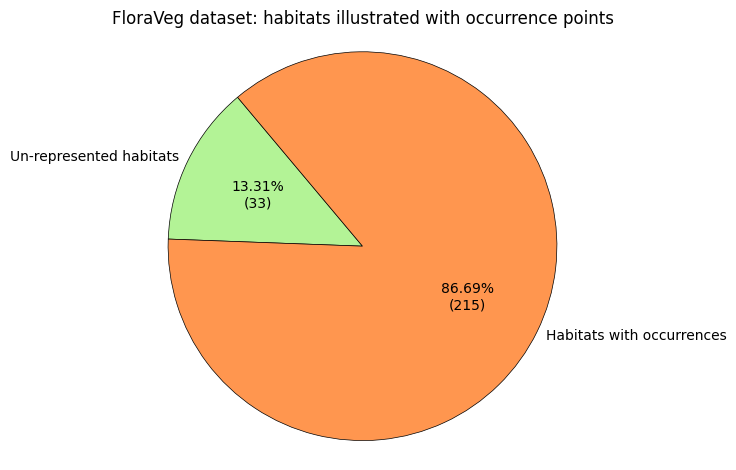
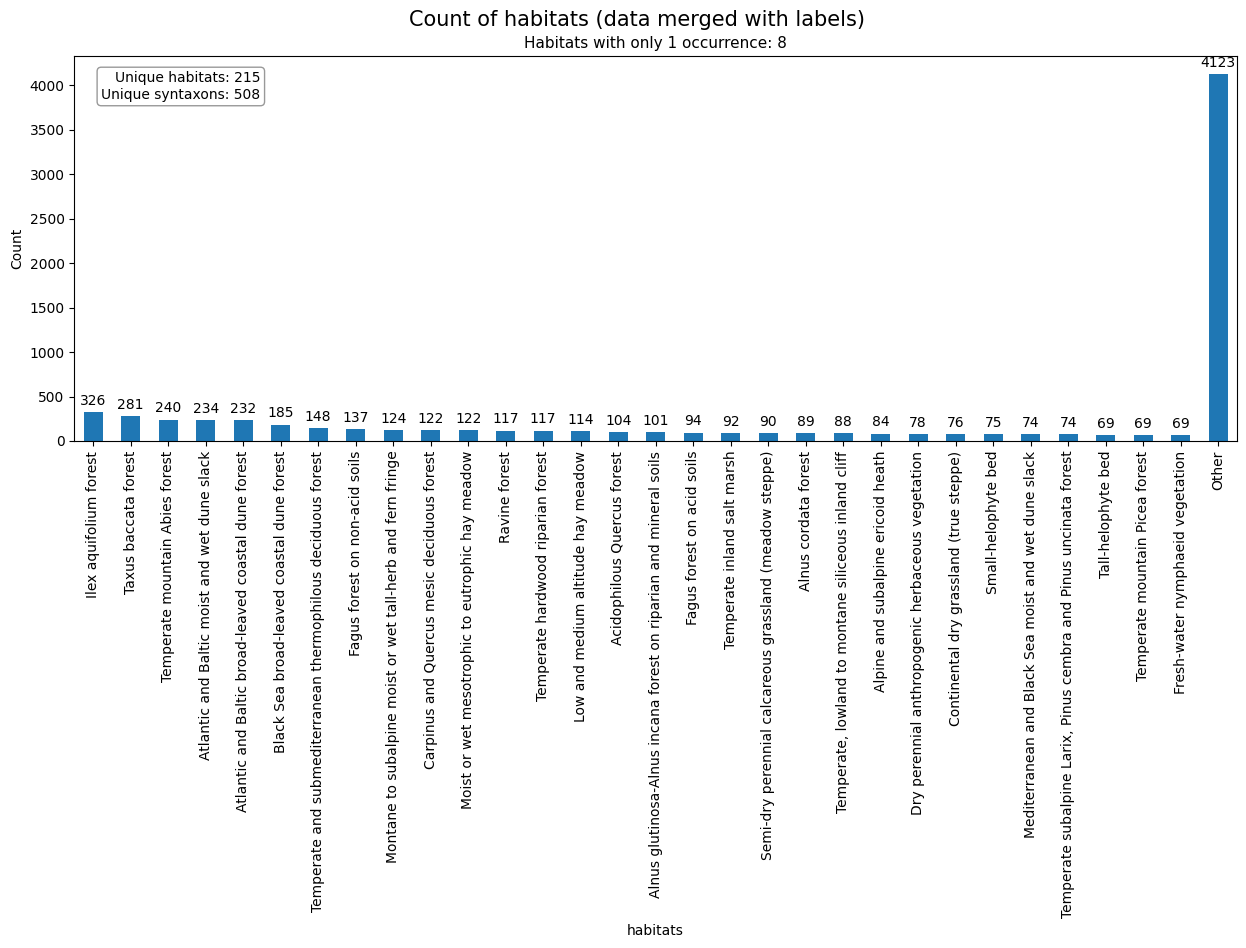

In [58]:
values = [df_labels_with_code['habitats'].nunique() - df_occurrences_merged['habitats_code'].nunique(),
          df_occurrences_merged['habitats_code'].nunique()]
labels = ['Un-represented habitats', 'Habitats with occurrences']
title = "FloraVeg dataset: habitats illustrated with occurrence points"

fig1 = pie_chart_simple(values, labels, title, fp_out='resources/FloraVeg_habitats_with_occu.png', plot=False)
fig2, habitat_counts_merge = bar_plot_distribution_with_floating_text(df_occurrences_merged, 'habitats', top_k=30, title='Count of habitats (data merged with labels)', plot_width=15, fp_out='resources/habitat_distribution_on_metadata_merged_with_labels.png', plot=False)

display_plots_side_by_side([fig1, fig2])


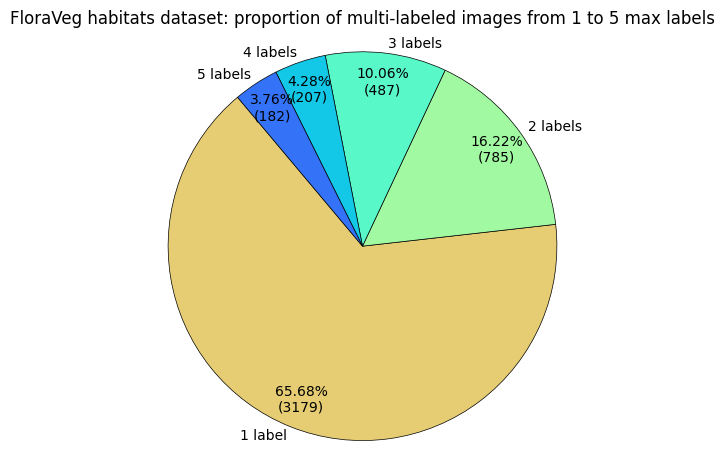
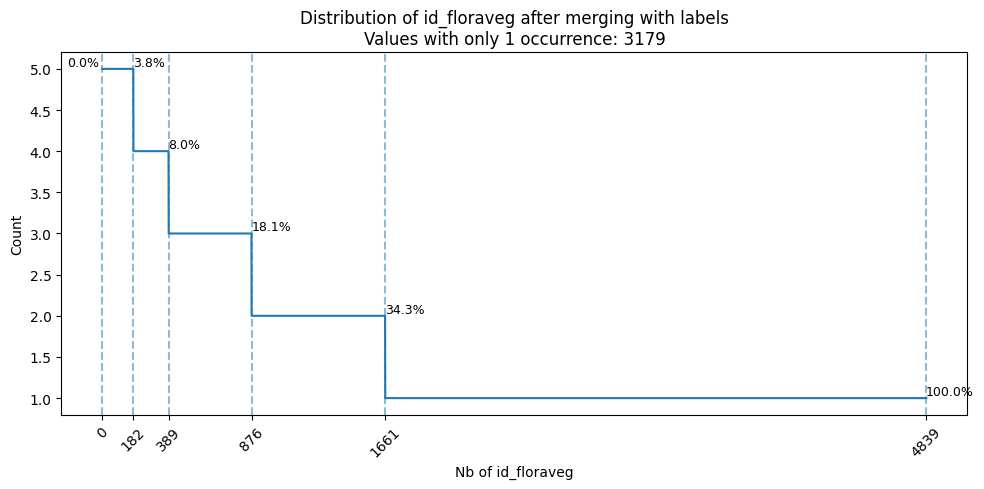

In [59]:
fig2, counts, df_counts_percentage = step_plot_distribution(df_occurrences_merged, 'id_floraveg',  fp_out='resources/occurrences_distribution_after_labels_merge.png', plot=False)
fig1 = pie_chart_multilabels_proportion(df_counts_percentage, fp_out='resources/Multi-labeled habitats proportion.png', plot=False)

display_plots_side_by_side([fig1, fig2])

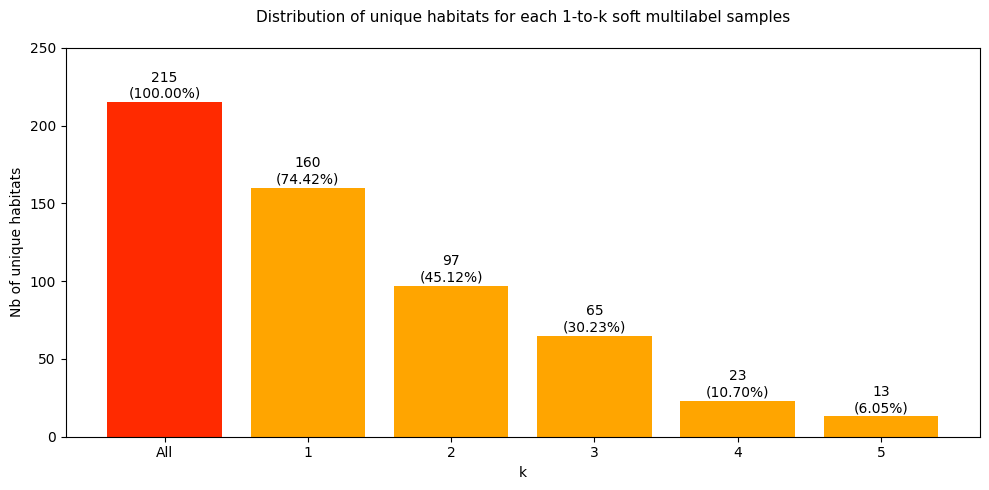

In [60]:
fig1 = bar_plot_habitats_soft_multilabel(df_occurrences_merged, counts, 'id_floraveg', fp_out='resources/Habitats_distribution_soft_multilabeling.png', plot=True)


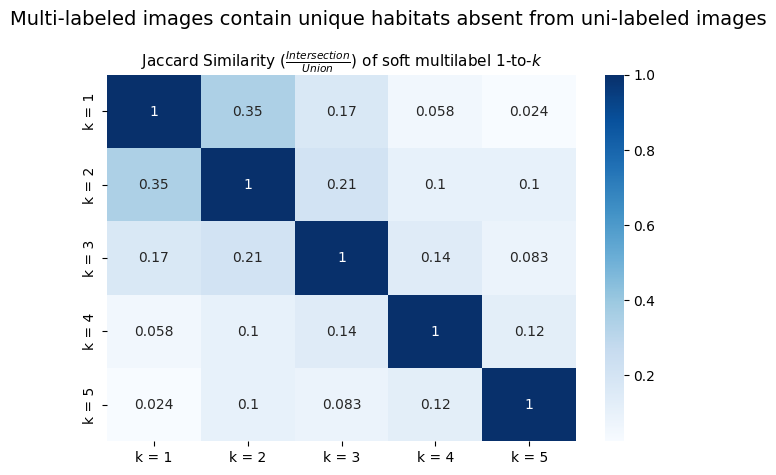
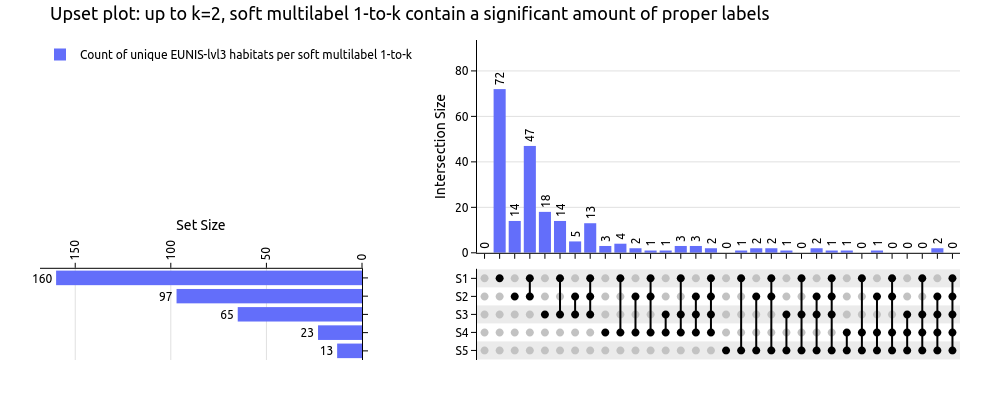

In [61]:
fig1 = upset_plot_habitats_per_soft_labeling(df_occurrences_merged, counts, plot=False)
fig2 = jaccard_sim_habitat_soft_multilabeling(counts, df_occurrences_merged, fp_out='resources/Jaccard_similarity_habitats_soft_labeling.png')
clear_output()
display_plots_side_by_side([fig2, 'resources/upset_plot_habitats_per_soft_labelling.png'])

### Distribution of habitat labels in partial multi-labeled images

To address the partial multi-labeling, various training strategies can be implemented:

- **B0.** **Pipeline level**: No sampling, iterate over the whole CSV sample-wise, and let the model see multiple times the same images with different labels
    - Upside: all labels are seen the same amount of times per batch
    - Downside: this will introduce bias
---
- **B1.** **Dataloader level**: Iterate over the unique FloraVeg IDs and randomly sample a label, per batch
    - Upside: easy to implement
    - Downside: if the multi-labeled images are often tied to the same labels, the later will be harder to predict because they will have been seen fewer times
---
- **B2.** **Loss level**: Compute a custom loss with that takes into account the multiplicity of labels and weighs everything to give equal weights to all labels
    - Upside: fine-grain solution with possible optimum in labels equity
    - Downside: hard to implement and tune

In [62]:
# df_occurrences_merged['habitats_code_lvl1'] = df_occurrences_merged['habitats_code'].apply(lambda x: re.match(r'[A-Za-z]+', x)[0])

df_occurrences_merged[df_occurrences_merged['id_floraveg'].isin(counts[counts > 1].index)].head(2)  # display samples of Ensembles 1-to-k with k>1

,filename_photos,syntaxon_floraveg,author_floraveg,country,id_floraveg,locality,author_name,domin_taxa,association,coords_precision,...,Level_4,habitats_code_lvl1,habitats_code_lvl2,habitats_code_lvl3,habitats_code_lvl4,habitats_code_ID_lvl1,habitats_code_ID_lvl2,habitats_code_ID_lvl3,habitats_code_ID_lvl4,habitats_code_ID
1,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,...,False,N,N1,N1D,,1,1,16,0,22
2,Carpinion_betuli_(eu)3.jpg,Carpinion betuli,Issler 1931,Bosnia and Herzegovina,14059,"Gradiška municipality, Cerovljani village, Dog...",Vladimir Stupar,"Carpinus betulus, Quercus robur",NaN,NaN,...,False,N,N1,N1E,,1,1,17,0,23


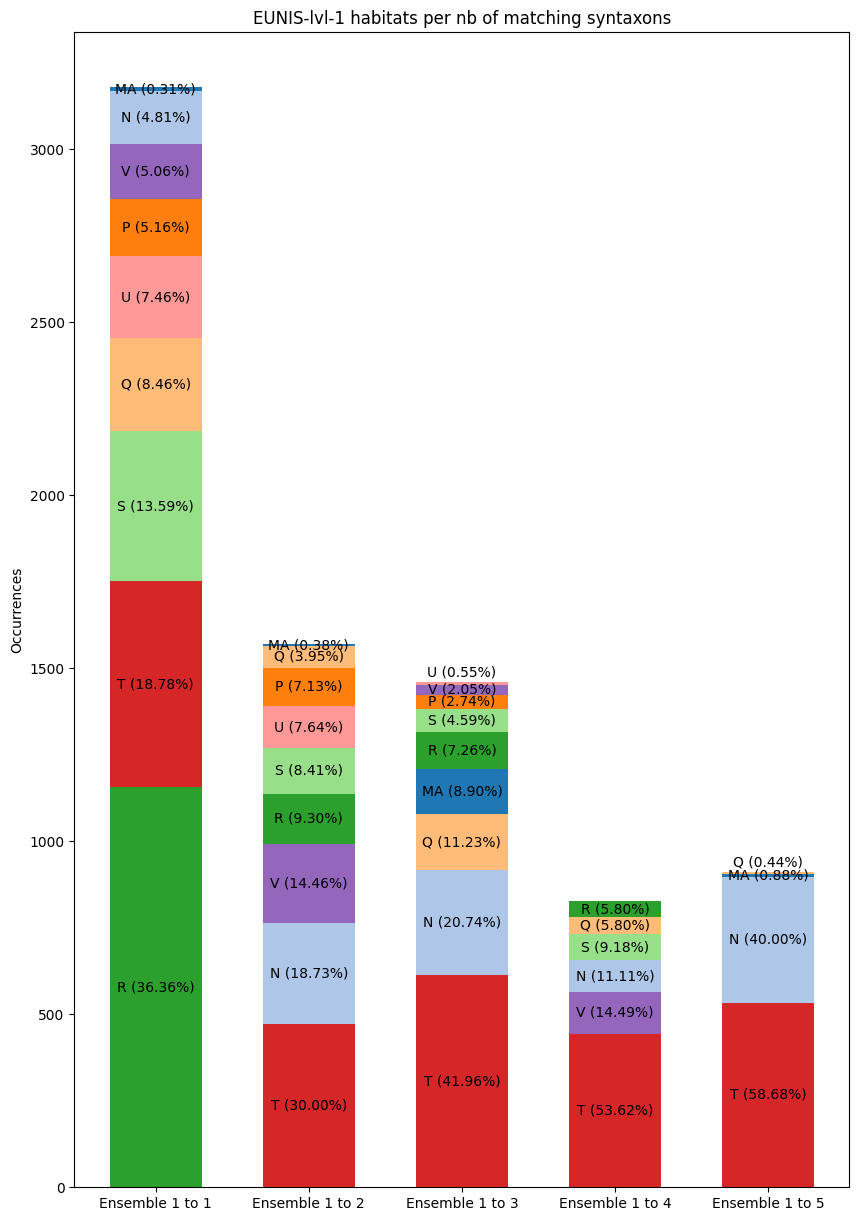

In [63]:
_ = stack_bars_habitats(df_occurrences_merged, counts, df_counts_percentage, fp_out='resources/Stack_bar_plot_multi-taxons_habitats.png', plot=True)

### ⚠️ Test split ⚠️
Several strategies are proposed to generate the test split:

- **S0: naive split** \
Splitting based on plot ID (id_floraveg).
    - _Advantages_: No image leakage between train & test due to the soft-multilabelling issue (contrary to S1).
    - _Drawbacks_: The distribution of k-soft multilabeled samples is NOT preserved. One split could have all the 1-to-5 samples when the other would have none.

---

- **S0-bis: naive split multilabel** \
Same as S0 but formats labels as strings for a multilabel purpose. There are as many rows as unique Floraveg IDs.
    - _Advantages_: Pre-formatted for multi-label prediction. No over-representation of 1-to-k samples in the CSV file (useful to avoid wrong metrics computations)

---

- **S1: stratified split (labels)** \
Splitting based on the distribution of labels, making sure each split has the same labels distribution (if possible).
    - _Advantages_: Preserves the labels distribution.
    - _Drawbacks_: There may be **data leakage** due to the fact that samples can have more than 2 labels, therefore a 3-multilabel plot (floraveg_id) could be split both to trian and test, with different labels.

---

- **S1-bis: stratified split (k)** \
Splitting based on the distribution of k-multilabeled plot ID (id_floraveg).
    - _Advantages_: Preserves the distribution of k-multilabels samples in train and test.
    - _Drawbacks_: Distribution of labels is NOT ensured. However there is no visual image data leakage between train and test.

---

- **S2: spatial split** \
Splitting based on geolocation. This method can only be performed over geo-tagged occurrences.
    - _Advantages_: Dampens potential geographical bias. No image data leakage because a plot (id_floraveg) is defined (partly ?) by its GPS coords; so selecting by GPS automatically selects entire plots regardless of the 1-to-k soft multilabelling effect.
    - _Drawbacks_: Looses 31.25% of available data (which is not geo-tagged). Does NOT preserve labels distribution.
    
---

- **S3: multilabel stratify**
Splitting based on [tent-b's multilabel implementation of sk-learn StratifiedSplit](https://github.com/trent-b/iterative-stratification). Proof of working by [gum-gum on Medium](https://medium.com/gumgum-tech/creating-balanced-multi-label-datasets-for-model-training-and-evaluation-16b6a3a2d912).
    - _Advantages_: Preserves class distribution in a multi-label setting with no need to duplicate occurrences.
    - _Drawbacks_: operates with binary multilabel formatting so need to re-format labels for this method specifically and re-format back to strings afterwards for export.


In [64]:
TEST_SIZE = 0.1

def concat_groupby(df, group_col="id_floraveg", sep=";"):
    """Group a dataframe by unique site and concatenates multilabel habitat labels as ;-separated strings."""
    df = df.fillna('nan')
    # Apply aggregation to all columns except the grouping one
    agg_dict = {
        col: (
            (lambda x: sep.join(x.astype(str)))
            if col in [
                'habitats_code', 'habitats_code_lvl1', 'habitats_code_lvl2', 'habitats_code_lvl3', 'habitats_code_lvl4',
                'habitats_code_ID', 'habitats_code_ID_lvl1', 'habitats_code_ID_lvl2', 'habitats_code_ID_lvl3', 'habitats_code_ID_lvl4',
            ] else
            ('first')
        )
        for col in df.columns if col != group_col
    }
    df_gb = df.groupby(group_col, as_index=False).agg(agg_dict)
    df_gb['filename_photos'] = df_gb['filename_photos'].apply(lambda x: x.split(sep)[0])
    return df_gb

def apply_str_to_oh(habitat_code, n_cls=215):
    """Translate ;-separated strings of IDs into one-hot vectors."""
    ids = np.array(habitat_code.split(';')).astype(int)
    ids_oh = np.zeros(n_cls, dtype=int)
    ids_oh[ids] = 1
    return ids_oh

def count_u_habitats_multilabel(df):
    u_habitats = {}
    for rowi, row in df.iterrows():
        ks = row['habitats_code'].split(';')
        for k in ks:
            u_habitats[k] = u_habitats.get(k, 0) + 1
    return u_habitats

- **S0 split**

In [16]:
def S0_split(df, out_name, val_size=0.1, random_state=42):
    unique_ids = df["id_floraveg"].unique()
    train_ids, val_ids = train_test_split(
        unique_ids,
        test_size=val_size,
        random_state=random_state
    )

    train_df = df[df["id_floraveg"].isin(train_ids)].copy()
    val_df = df[df["id_floraveg"].isin(val_ids)].copy()

    train_path = f"{out_name}_train.csv"
    val_path = f"{out_name}_test.csv"

    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)

    print(f"Train saved to: {train_path}")
    print(f"Val saved to: {val_path}")
    print(f"Train size: {len(train_df)}")
    print(f"Val size: {len(val_df)}")

    return train_df, val_df

S0_train_df, S0_test_df = S0_split(df_occurrences_merged, 'metadata_labels_merged_S0-10%', val_size=0.10)

Train saved to: metadata_labels_merged_S0-10%_train.csv
Val saved to: metadata_labels_merged_S0-10%_test.csv
Train size: 7138
Val size: 810


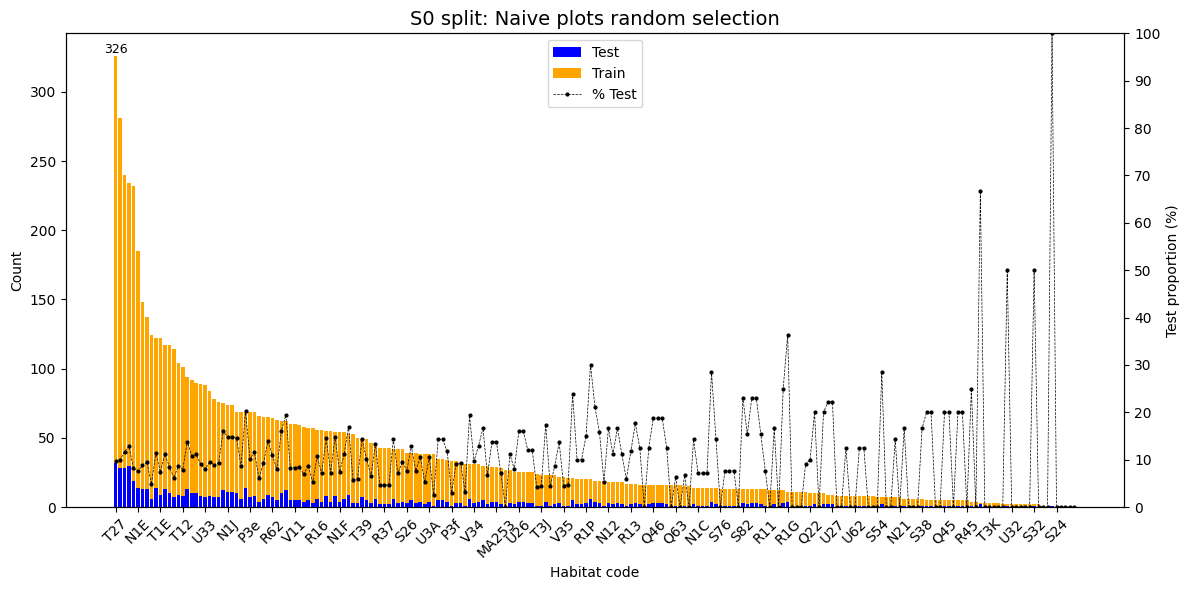

In [17]:
fig0 = stacked_bars_habitat_distribution(S0_train_df, S0_test_df, title='S0 split: Naive plots random selection', fp_out='resources/S0_split.png')

In [41]:
def S0_bis_split(df, out_name, test_size=0.1, random_state=42): 
    unique_ids = df["id_floraveg"].unique()
    train_ids, test_ids = train_test_split(
        unique_ids,
        test_size=test_size,
        random_state=random_state
    )

    train_df = df[df["id_floraveg"].isin(train_ids)].copy()
    test_df = df[df["id_floraveg"].isin(test_ids)].copy()
    
    train_df = concat_groupby(train_df)
    test_df = concat_groupby(test_df)

    train_path = f"{out_name}_train.csv"
    test_path = f"{out_name}_test.csv"

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"Train saved to: {train_path}")
    print(f"Val saved to: {test_path}")
    print(f"Train size: {len(train_df)}")
    print(f"Val size: {len(test_df)}")

    return train_df, test_df

S0_bis_train_df, S0_bis_test_df = S0_bis_split(df_occurrences_merged, 'TMP_metadata_labels_merged_S0bis-10%', test_size=0.10)

4840
Train saved to: TMP_metadata_labels_merged_S0bis-10%_train.csv
Val saved to: TMP_metadata_labels_merged_S0bis-10%_test.csv
Train size: 4356
Val size: 484


- **S3 split**

In [21]:
def S3_split(df, out_name, test_size=0.1, random_state=42):
    df_gb = concat_groupby(df)
    # Add binary encoding for each level (on a dataframe already GROUPED BY sites)
    df_gb['habitats_code_ID_oh'] = df_gb['habitats_code_ID'].apply(apply_str_to_oh, n_cls=int(df['habitats_code_ID'].max())+1)
    df_gb['habitats_code_ID_oh_lvl1'] = df_gb['habitats_code_ID_lvl1'].apply(apply_str_to_oh, n_cls=int(df['habitats_code_ID_lvl1'].max())+1)
    df_gb['habitats_code_ID_oh_lvl2'] = df_gb['habitats_code_ID_lvl2'].apply(apply_str_to_oh, n_cls=int(df['habitats_code_ID_lvl2'].max())+1)
    df_gb['habitats_code_ID_oh_lvl3'] = df_gb['habitats_code_ID_lvl3'].apply(apply_str_to_oh, n_cls=int(df['habitats_code_ID_lvl3'].max())+1)
    df_gb['habitats_code_ID_oh_lvl4'] = df_gb['habitats_code_ID_lvl4'].apply(apply_str_to_oh, n_cls=int(df['habitats_code_ID_lvl4'].max())+1)

    # Apply train/test split while applying label stratification in a multilabe setup.
    # NOTE: this method is label-order invariant since it is based on one-hot y vectors
    y = np.stack(df_gb['habitats_code_ID_oh'].values)
    X = np.zeros(len(y))
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    train_idx, test_idx = next(msss.split(X, y))

    df_gb_mlstratified_train = df_gb.iloc[train_idx]
    df_gb_mlstratified_test = df_gb.iloc[test_idx]
    
    train_path = f"{out_name}_train.csv"
    test_path = f"{out_name}_test.csv"

    df_gb_mlstratified_train.to_csv(train_path, index=False)
    df_gb_mlstratified_test.to_csv(test_path, index=False)
    
    print(f"Train saved to: {train_path}")
    print(f"Test saved to: {test_path}")
    print(f"Train size: {len(df_gb_mlstratified_train)}")
    print(f"Test size: {len(df_gb_mlstratified_test)}")
    
    return df_gb_mlstratified_train, df_gb_mlstratified_test

S3_train_df, S3_test_df = S3_split(df_occurrences_merged, 'metadata_labels_merged_S3-10%_extended', test_size=0.10)

Train saved to: metadata_labels_merged_S3-10%_extended_train.csv
Test saved to: metadata_labels_merged_S3-10%_extended_test.csv
Train size: 4376
Test size: 464



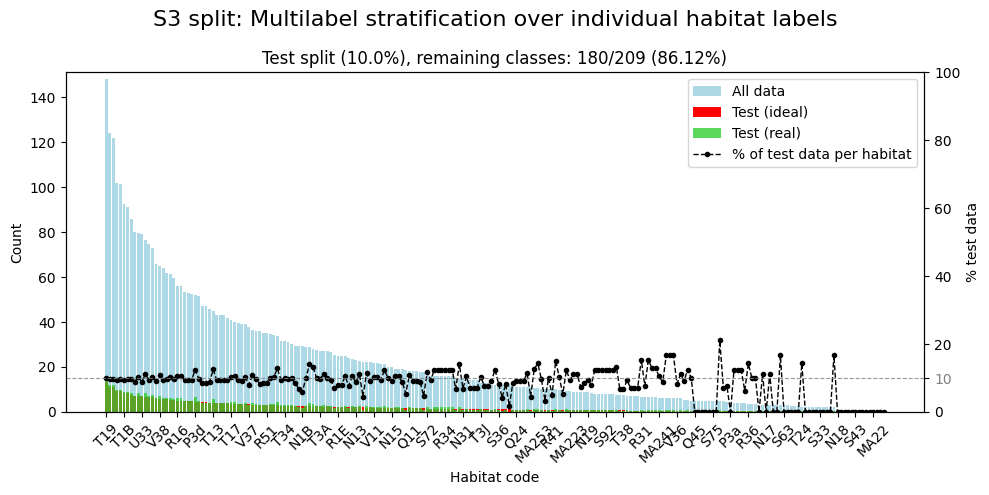
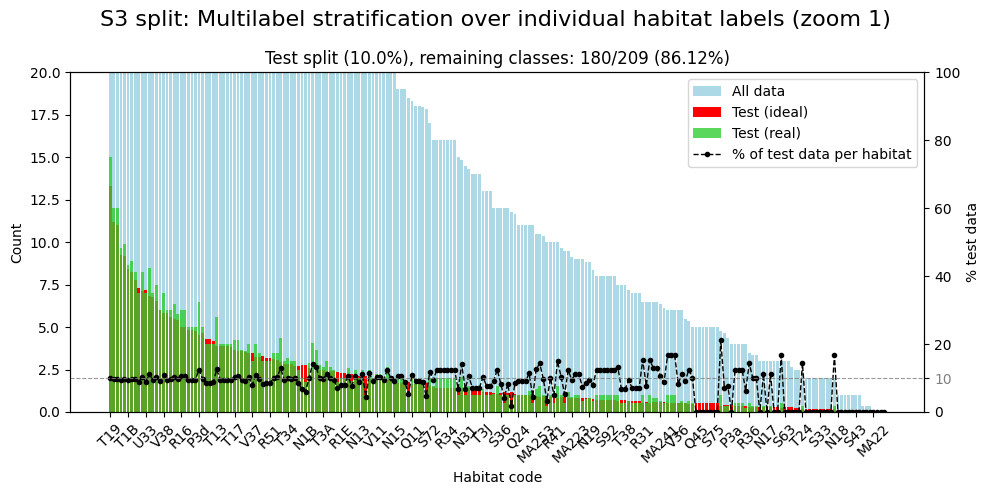
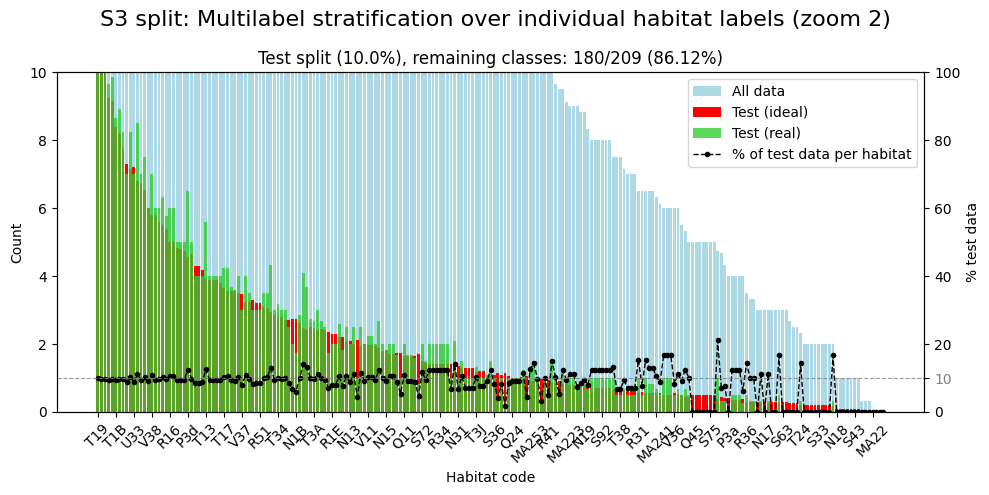

In [22]:
S3_df = pd.concat([S3_train_df, S3_test_df])

def get_u_habitats_distrib(df, total_cls):
    """Counts the number of habitat labels from a dataframe and outputs 2 dicts: absolute count & scaled values (relative to the nb of id_floraveg)"""
    # We are looking for the distribution of the unique habitats, NOT the assemblages
    u_habitats = {k: 0 for k in total_cls}
    for rowi, row in df.iterrows():
        h_c = row['habitats_code'].split(';')
        for k in h_c:
            u_habitats[k] = 1/len(h_c) if k not in u_habitats.keys() else u_habitats[k] + 1/len(h_c)
    u_habitats = dict(sorted(u_habitats.items(), key=lambda item: item[0], reverse=False))
    assert sum(u_habitats.values()) == len(df)


    u_habitats_norm = {k: v/sum(u_habitats.values()) for k, v in u_habitats.items()}
    return u_habitats, u_habitats_norm

df_gb_uh_distrib, df_gb_uh_distrib_norm = get_u_habitats_distrib(S3_df, le_lvl3.classes_)  # Before split
# S3_uh_distrib, S3_uh_distrib_norm = get_u_habitats_distrib(S3_df, le_lvl3.classes_)  # After split: All
S3_train_uh_distrib, S3_train_uh_distrib_norm = get_u_habitats_distrib(S3_train_df, le_lvl3.classes_)  # Train split
S3_test_uh_distrib, S3_test_uh_distrib_norm = get_u_habitats_distrib(S3_test_df, le_lvl3.classes_)  # Test split
ideal_test_distrib = {k:v*TEST_SIZE for k,v in S3_train_uh_distrib.items()}  # Ideal test split

test_n_habitats = len({k:v for k,v in S3_test_uh_distrib.items() if v>0})
fig1 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=151,
    fp_out='S3_split.png',
)
    
fig2 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels (zoom 1)',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=20,
    fp_out='S3_split_zoom1.png',
)

    
fig3 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels (zoom 2)',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=10,
    fp_out='S3_split_zoom2.png',
)

display_plots_side_by_side([fig1, fig2, fig3])


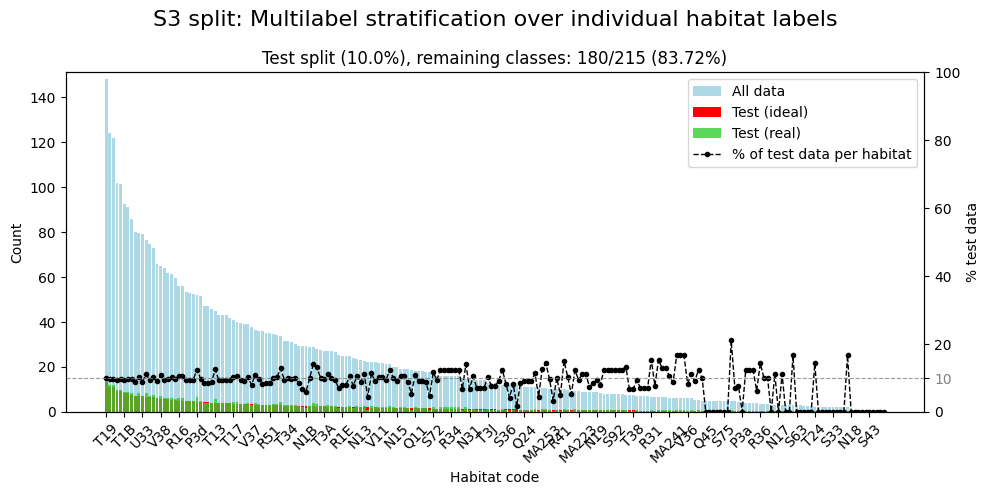
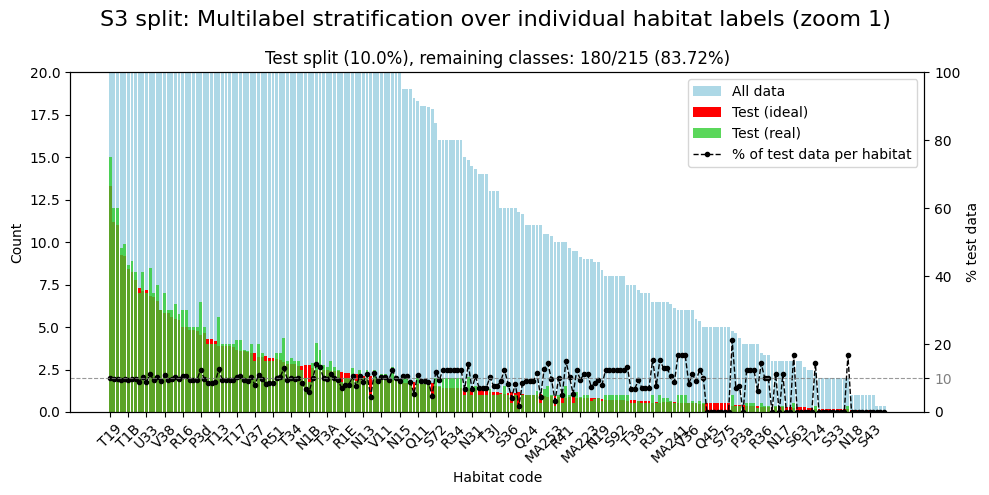
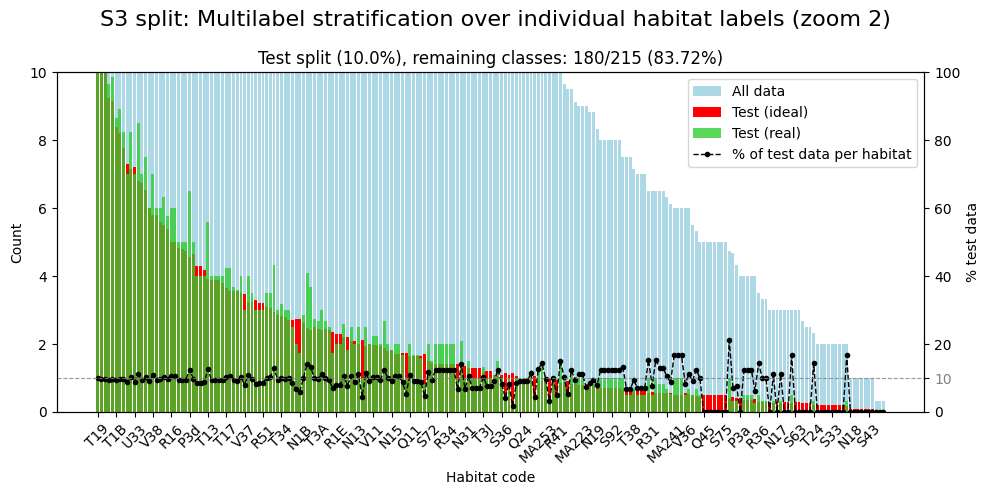

In [93]:
S3_df = pd.concat([S3_train_df, S3_test_df])

def get_u_habitats_distrib(df, total_cls):
    """Counts the number of habitat labels from a dataframe and outputs 2 dicts: absolute count & scaled values (relative to the nb of id_floraveg)"""
    # We are looking for the distribution of the unique habitats, NOT the assemblages
    u_habitats = {k: 0 for k in total_cls}
    for rowi, row in df.iterrows():
        h_c = row['habitats_code'].split(';')
        for k in h_c:
            u_habitats[k] = 1/len(h_c) if k not in u_habitats.keys() else u_habitats[k] + 1/len(h_c)
    u_habitats = dict(sorted(u_habitats.items(), key=lambda item: item[0], reverse=False))
    assert sum(u_habitats.values()) == len(df)


    u_habitats_norm = {k: v/sum(u_habitats.values()) for k, v in u_habitats.items()}
    return u_habitats, u_habitats_norm

df_gb_uh_distrib, df_gb_uh_distrib_norm = get_u_habitats_distrib(S3_df, le_lvl3.classes_)  # Before split
# S3_uh_distrib, S3_uh_distrib_norm = get_u_habitats_distrib(S3_df, le_lvl3.classes_)  # After split: All
S3_train_uh_distrib, S3_train_uh_distrib_norm = get_u_habitats_distrib(S3_train_df, le_lvl3.classes_)  # Train split
S3_test_uh_distrib, S3_test_uh_distrib_norm = get_u_habitats_distrib(S3_test_df, le_lvl3.classes_)  # Test split
ideal_test_distrib = {k:v*TEST_SIZE for k,v in S3_train_uh_distrib.items()}  # Ideal test split

test_n_habitats = len({k:v for k,v in S3_test_uh_distrib.items() if v>0})
fig1 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=151,
    fp_out='S3_split.png',
)
    
fig2 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels (zoom 1)',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=20,
    fp_out='S3_split_zoom1.png',
)

    
fig3 = plot_stacked_bar_multilabel_stratify(
    df_gb_uh_distrib, ideal_test_distrib, S3_test_uh_distrib,
    suptitle='S3 split: Multilabel stratification over individual habitat labels (zoom 2)',
    title=f'Test split ({100*TEST_SIZE}%), remaining classes: {test_n_habitats}/{len(le_lvl3.classes_)} ({(100*test_n_habitats/len(le_lvl3.classes_)):.2f}%)',
    label1="All data", label2="Test (ideal)", label3="Test (real)",
    y_min=0, y_max=10,
    fp_out='S3_split_zoom2.png',
)

display_plots_side_by_side([fig1, fig2, fig3])

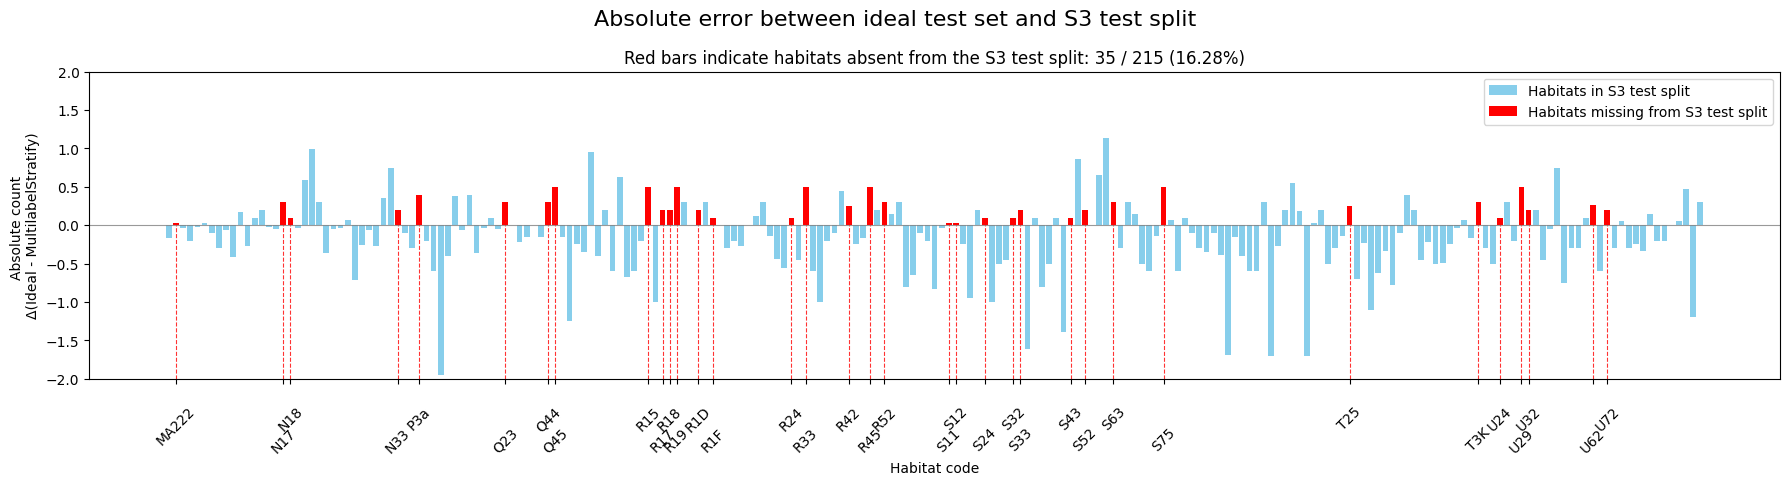

In [94]:
def plot_dict_bar(data_dict, x_missing, title="Bar Plot", xlabel="Bins", ylabel="Values", y_min=-1, y_max=15, fp_out=False):
    # Extract keys and values
    bins = list(data_dict.keys())
    values = list(data_dict.values())
    
    # Assign colors
    colors = []
    for i, b in enumerate(bins):
        if b in list(set(bins)-set(x_missing)):
            colors.append("skyblue")
        elif b in x_missing:
            colors.append("red")
        else:
            colors.append("gray")  # default color

    fig, ax = plt.subplots(figsize=(18, 5))
    ax.bar(bins, values, color=colors)
    ax.axhline(y=0, linestyle='-', linewidth=0.8, alpha=0.8, c='gray')

    # Labels and title
    plt.suptitle(title, fontsize=16)
    ax.set_title(f'Red bars indicate habitats absent from the S3 test split: {len(x_missing)} / {len(bins)} ({100*len(x_missing)/len(bins):.2f}%)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Set fixed y-axis limits if provided
    if y_min is not None or y_max is not None:
        ax.set_ylim(bottom=y_min, top=y_max)

    # Rotate labels if long
    ax.set_xticks(x_missing, x_missing, rotation=45)
    for x in x_missing:
        ax.axvline(x=x, ymax=0.5, linestyle='--', linewidth=0.8, alpha=0.8, c='red')
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 == 0:
            label.set_y(-0.05)   # default is ~0
        else:
            label.set_y(-0.12)

    legend_elements = [
        Patch(facecolor='skyblue', label='Habitats in S3 test split'),
        Patch(facecolor='red', label='Habitats missing from S3 test split')
    ]
    ax.legend(handles=legend_elements)

    # Better spacing
    plt.tight_layout()
    
    if fp_out:
        fig.savefig(fp_out, bbox_inches='tight')

    # Show plot
    plt.show()

tmp = {k: ideal_test_distrib[k] - S3_test_uh_distrib[k] for k in ideal_test_distrib}
plot_dict_bar(tmp,
              list({k:v for (k,v), (k_ideal, v_ideal) in zip(tmp.items(), ideal_test_distrib.items()) if v>=v_ideal}.keys()),
              title='Absolute error between ideal test set and S3 test split', xlabel='Habitat code', ylabel='Absolute count \nΔ(Ideal - MultilabelStratify)',
              y_max=2, y_min=-2,
              fp_out='S3_split_absolute_error.png',
)

- **S1 split**


In [ ]:
from toolbox.split_obs_per_column_frequency import main as split_obs_per_column_frequency

input_path = 'metadata_labels_merged_encoded.csv'
output_name = 'metadata_labels_merged_S1_stratified'
filter_id = 'habitats_code'
sep = ','
val_ratio = 0.1033
keep_rares = 1

split_obs_per_column_frequency(input_path, output_name, filter_id, sep, val_ratio, keep_rares)

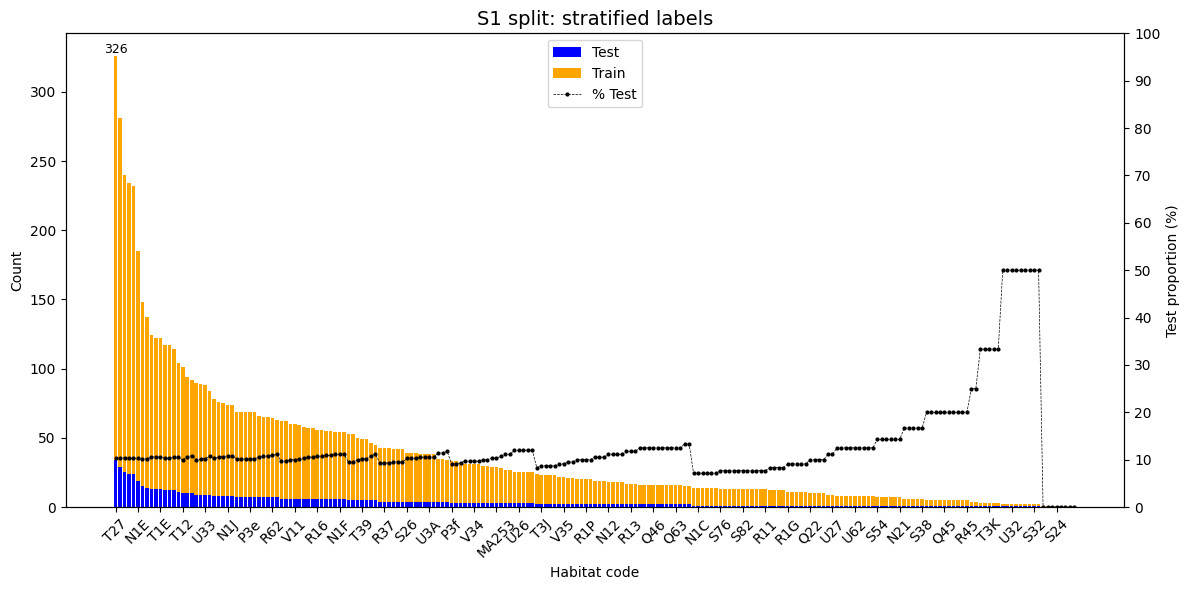

In [137]:
S1_train_df = pd.read_csv('metadata_labels_merged_S1_stratified_split-10.33%_train.csv')
S1_test_df = pd.read_csv('metadata_labels_merged_S1_stratified_split-10.33%_test.csv')
fig1 = stacked_bars_habitat_distribution(S1_train_df, S1_test_df, title='S1 split: stratified labels', suptitle='', fp_out='resources/S1_split.png')

- **S1-bis split**

In [35]:
def S1_bis_split(df, out_name, test_size=0.1, random_state=42):
    counts_per_k_multilabel = counts.groupby(counts).groups
    train_ids_multi_k, test_ids_multi_k = [], []
    for k, ids in counts_per_k_multilabel.items():
        df_k = df[df['id_floraveg'].isin(ids)]
        train_ids, test_ids = train_test_split(
            df_k["id_floraveg"].unique(),
            test_size=test_size,
            random_state=random_state
        )
        train_ids_multi_k.extend(train_ids)
        test_ids_multi_k.extend(test_ids)

    train_df = df[df["id_floraveg"].isin(train_ids_multi_k)].copy()
    test_df = df[df["id_floraveg"].isin(test_ids_multi_k)].copy()
    train_path = f"{out_name}_train.csv"
    test_path = f"{out_name}_test.csv"

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"Train saved to: {train_path}")
    print(f"Test saved to: {test_path}")
    print(f"Train size: {len(train_df)}")
    print(f"Test size: {len(test_df)}")

    return train_df, test_df

S1_bis_train_df, S1_bis_test_df = S1_bis_split(df_occurrences_merged, 'metadata_labels_merged_S1bis-10%', test_size=0.10)

InvalidParameterError: The 'test_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 1.0 instead.

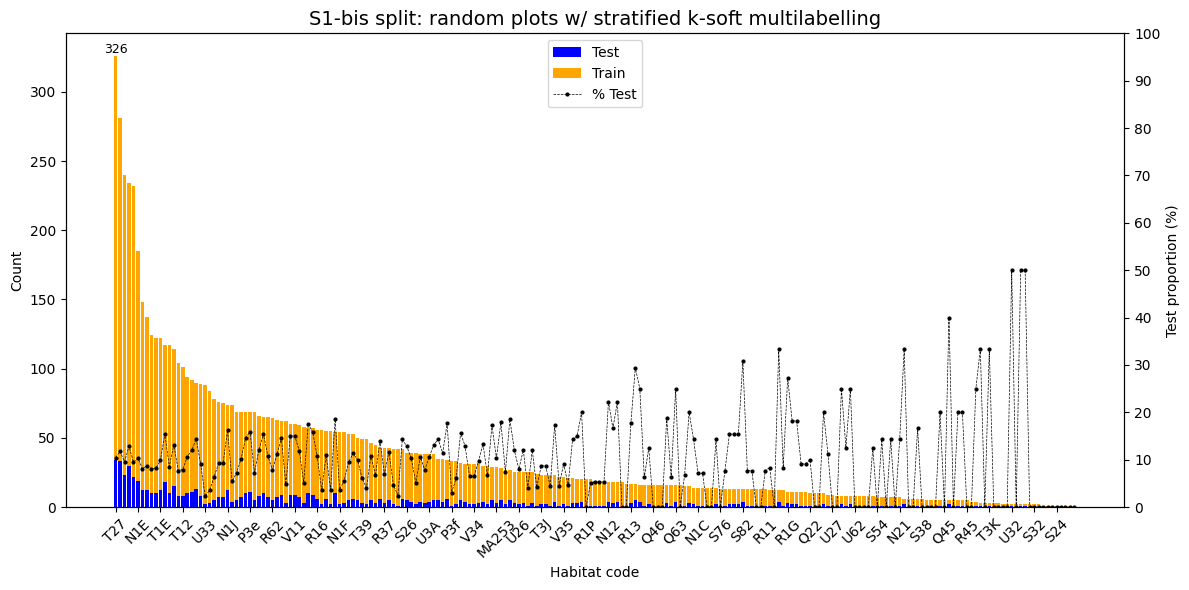

In [117]:
fig1_bis = stacked_bars_habitat_distribution(S1_bis_train_df, S1_bis_test_df, title='S1-bis split: random plots w/ stratified k-soft multilabelling', fp_out='resources/S1-bis_split.png')

- **S2 split**

In [149]:
df_S3 = pd.read_csv('metadata_labels_merged_gps_only_S2-10%_train_test-500m.csv')  # 500m, 61.79% of classes in test
df_S3_train = pd.read_csv('metadata_labels_merged_gps_only_S2-10%_train-500m.csv')
df_S3_test = pd.read_csv('metadata_labels_merged_gps_only_S2-10%_test-500m.csv')
# df_S3_train = pd.read_csv('metadata_labels_merged_gps_only_S2_encoded_train-0.135min.csv')  
# df_S3_test = pd.read_csv('metadata_labels_merged_gps_only_S2_encoded_test-0.135min.csv')  # ~250m, 74.41% of classes in test
c_uh = count_u_habitats_multilabel(df)
c_uh_train = count_u_habitats_multilabel(df_S3_train)
c_uh_test = count_u_habitats_multilabel(df_S3_test)
print(len(c_uh))
print(len(c_uh_train))
print(len(c_uh_test))
print(f'{100*len(c_uh_test)/len(c_uh_train):.2f}%')

213
212
131
61.79%


In [30]:
df_gps_gb = concat_groupby(df_occurrences_merged_gps_only)
# Add binary encoding for each level (on a dataframe already GROUPED BY sites)
df_gps_gb['habitats_code_ID_oh'] = df_gps_gb['habitats_code_ID'].apply(apply_str_to_oh, n_cls=int(df_occurrences_merged_gps_only['habitats_code_ID'].max())+1)
df_gps_gb['habitats_code_ID_oh_lvl1'] = df_gps_gb['habitats_code_ID_lvl1'].apply(apply_str_to_oh, n_cls=int(df_occurrences_merged_gps_only['habitats_code_ID_lvl1'].max())+1)
df_gps_gb['habitats_code_ID_oh_lvl2'] = df_gps_gb['habitats_code_ID_lvl2'].apply(apply_str_to_oh, n_cls=int(df_occurrences_merged_gps_only['habitats_code_ID_lvl2'].max())+1)
df_gps_gb['habitats_code_ID_oh_lvl3'] = df_gps_gb['habitats_code_ID_lvl3'].apply(apply_str_to_oh, n_cls=int(df_occurrences_merged_gps_only['habitats_code_ID_lvl3'].max())+1)
df_gps_gb['habitats_code_ID_oh_lvl4'] = df_gps_gb['habitats_code_ID_lvl4'].apply(apply_str_to_oh, n_cls=int(df_occurrences_merged_gps_only['habitats_code_ID_lvl4'].max())+1)
df_gps_gb.to_csv('metadata_labels_merged_gps_only_encoded_gb.csv', sep=',', index=False)

In [ ]:
from toolbox.split_obs_spatially import main as split_obs_spatially

input_path = 'metadata_labels_merged_gps_only_encoded_gb.csv'
spacing =  0.00250 # 0.135arc-minutes ~1km
col_lon = 'lon'
col_lat = 'lat'
val_size = 0.1033  # 530 occurrences
plot = False

split_obs_spatially(input_path, spacing=spacing, source_crs='EPSG:4326', spacing_crs='EPSG:4326', plot=plot, val_size=val_size, col_lon=col_lon, col_lat=col_lat)

/!\ illustration no longer matches the current files /!\

<div style="display: flex; gap: 10px; align-items: center;">
  <img src="resources/FloraVeg_Europe_data_split_0.54min.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
  <img src="resources/FloraVeg_spatial_split_0.54min.png" style="max-height: 700px; height: auto; width: auto; margin: 10px">
</div>

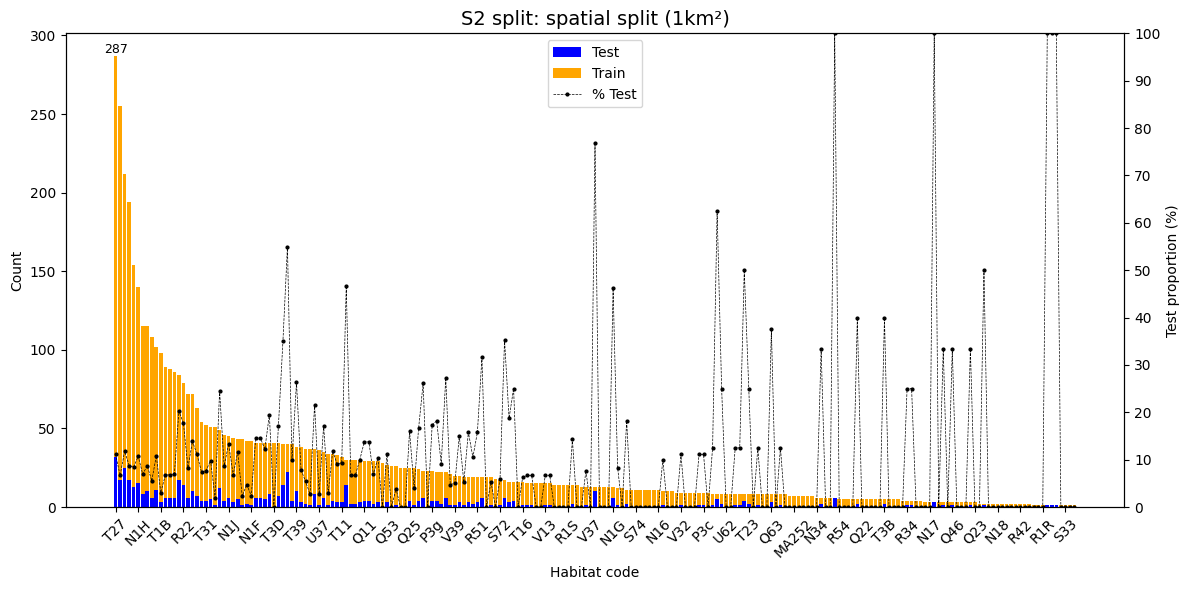

In [146]:
S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_S2_train-0.54min.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_S2_test-0.54min.csv')
fig2 = stacked_bars_habitat_distribution(S2_train_df, S2_test_df, title='S2 split: spatial split (1km²)', fp_out='resources/S2_split.png')

In [82]:
def check_train_test_overlap(df_train, df_test):
    overlap = len(np.intersect1d(df_train['id_floraveg'], df_test['id_floraveg']))
    if overlap > 0:
        print(f'⚠️ S2 split has {overlap} images leaking from train to test. ⚠️')
    else:
        print('✅ S2 split (spatial) has NO image leakage between train and test. ✅')

In [84]:
S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_S2-10%_train-500m.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_S2-10%_test-500m.csv')
print('\nS2 10%, 500m: ', len(count_u_habitats_multilabel(S2_test_df)) / len(count_u_habitats_multilabel(S2_train_df)))
check_train_test_overlap(S2_train_df, S2_test_df)

S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_S2_train-0.54min.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_S2_test-0.54min.csv')
print('\nS2 10%, 0.54min: ', len(count_u_habitats_multilabel(S2_test_df)) / len(count_u_habitats_multilabel(S2_train_df)))
check_train_test_overlap(S2_train_df, S2_test_df)

S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_encoded_gb-16.2%_train-500m.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_encoded_gb-16.2%_test-500m.csv')
print('\nS2 16.2%, 500m: ', len(count_u_habitats_multilabel(S2_test_df)) / len(count_u_habitats_multilabel(S2_train_df)))
check_train_test_overlap(S2_train_df, S2_test_df)

S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_encoded_gb-16.2%_train-250m.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_encoded_gb-16.2%_test-250m.csv')
print('\nS2 16.2%, 250m: ', len(count_u_habitats_multilabel(S2_test_df)) / len(count_u_habitats_multilabel(S2_train_df)))
check_train_test_overlap(S2_train_df, S2_test_df)

S2_train_df = pd.read_csv('metadata_labels_merged_gps_only_S2_encoded_train-0.00225deg.csv')               
S2_test_df = pd.read_csv('metadata_labels_merged_gps_only_S2_encoded_test-0.00225deg.csv')
print('\nS2 15.39%, 0.00225deg (~250m) /!\ NOT MULTILABEL,  n_ROWS =/= n_UNIQUE IDs /!\ :', len(count_u_habitats_multilabel(S2_test_df)) / len(count_u_habitats_multilabel(S2_train_df)))
check_train_test_overlap(S2_train_df, S2_test_df)


S2 10%, 500m:  0.6179245283018868
✅ S2 split (spatial) has NO image leakage between train and test. ✅

S2 10%, 0.54min:  0.5769230769230769
✅ S2 split (spatial) has NO image leakage between train and test. ✅

S2 16.2%, 500m:  0.6650717703349283
✅ S2 split (spatial) has NO image leakage between train and test. ✅

S2 16.2%, 250m:  0.7061611374407583
✅ S2 split (spatial) has NO image leakage between train and test. ✅

S2 15.39%, 0.00225deg (~250m) /!\ NOT MULTILABEL,  n_ROWS =/= n_UNIQUE IDs /!\ : 0.7440758293838863
⚠️ S2 split has 505 images leaking from train to test. ⚠️


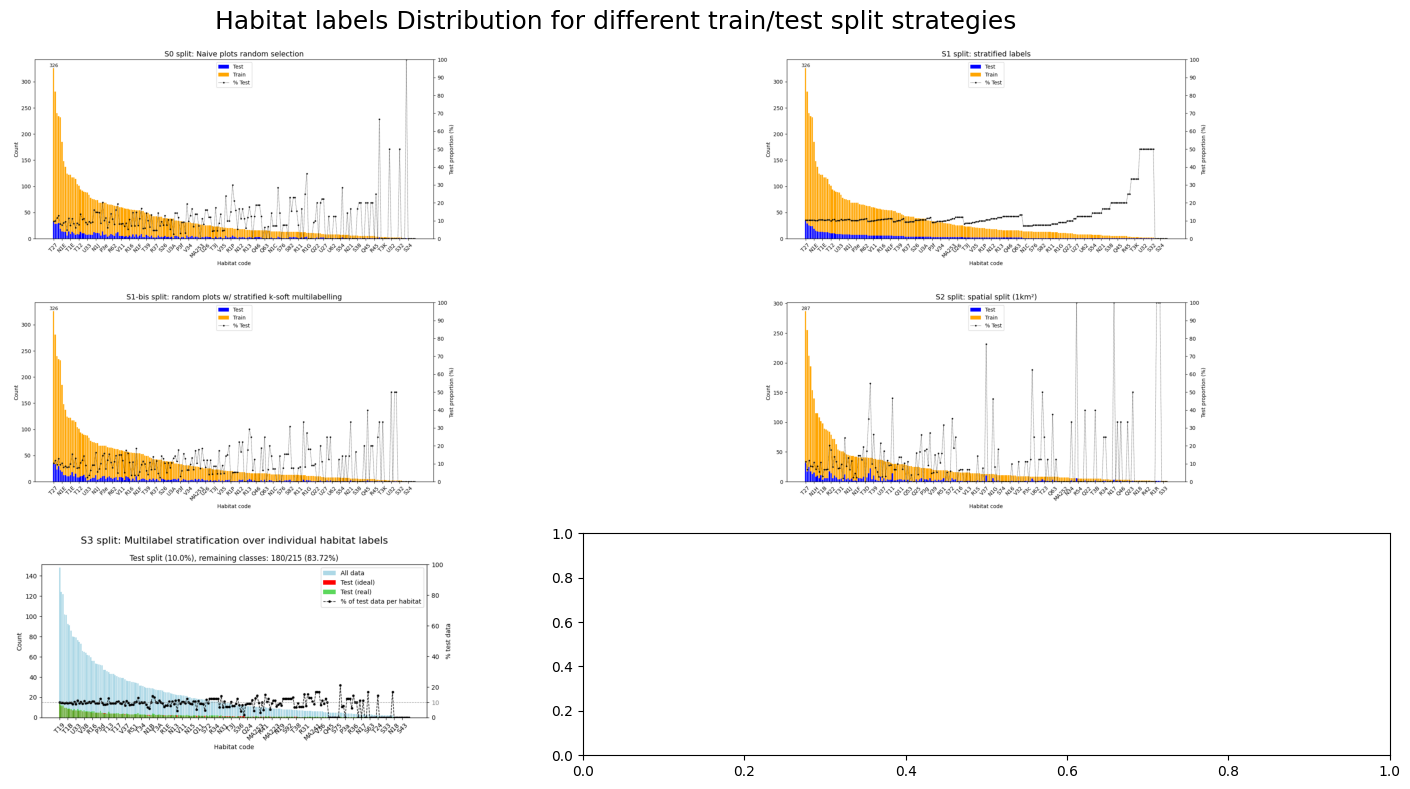

In [456]:
from PIL import Image

paths = [
    "resources/S0_split.png",
    "resources/S1_split.png",
    "resources/S1-bis_split.png",
    "resources/S2_split.png",
    "resources/S3_split.png"
]

# Load images
images = [Image.open(p) for p in paths]

# Create grid
fig, axs = plt.subplots(3, 2, figsize=(16, 8))

for ax, img in zip(axs.flatten(), images):
    ax.imshow(img)
    ax.axis("off")  # hide axes

plt.suptitle('Habitat labels Distribution for different train/test split strategies', fontsize=18)
plt.tight_layout()
plt.show()

## Test set 1-to-k img-label correspondance

In [457]:
df_test_stratified_filename = 'metadata_labels_merged_S1_stratified_split-10.33%_test'
df_test_spatial_filename = 'metadata_labels_merged_gps_only_S2_test-0.54min'
df_test_S1bis_filename = 'metadata_labels_merged_S1bis-10%_test'
df_test_S0bis_filename = 'metadata_labels_merged_S0bis-10%_test'
df_train_S0bis_filename = 'metadata_labels_merged_S0bis-10%_train'
df_train_S3_filename = 'metadata_labels_merged_S3-10%_train'
df_test_S3_filename = 'metadata_labels_merged_S3-10%_test'

df_test_freq = pd.read_csv(f'{df_test_stratified_filename}.csv')
df_test_spatial = pd.read_csv(f'{df_test_spatial_filename}.csv')
df_test_S1bis = pd.read_csv(f'{df_test_S1bis_filename}.csv')
df_test_S0bis = pd.read_csv(f'{df_test_S0bis_filename}.csv')
df_train_S0bis = pd.read_csv(f'{df_train_S0bis_filename}.csv')
df_train_S3 = pd.read_csv(f'{df_train_S3_filename}.csv')
df_test_S3 = pd.read_csv(f'{df_test_S3_filename}.csv')

samples_per_n_labels = counts.groupby(counts).groups

In [459]:
dfs_in = {
    # 'S1 (stratified labels)': df_test_freq,
    # 'S2 (spatial)': df_test_spatial,
    f'{df_test_S3_filename}': df_test_S3,
}

for name_in, df_in in dfs_in.items():
    print(f'>>> {name_in}')
    df_out = {}
    for k, ids in samples_per_n_labels.items():
        df_out[k] = df_in[df_in['id_floraveg'].isin(ids)]

    verif_size = 0
    ulabels = 0
    for k, df in df_out.items():
        df.to_csv(f'{name_in}_1-to-{k}.csv')
        verif_size += len(df)
        ulabels += df['habitats_code'].nunique()
        print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')

    print(f'Split df ({name_in} split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)\n')

>>> metadata_labels_merged_S3-10%_test
Nb of samples for k = 1: 296 with 104 unique labels.
Nb of samples for k = 2: 80 with 39 unique labels.
Nb of samples for k = 3: 49 with 23 unique labels.
Nb of samples for k = 4: 20 with 6 unique labels.
Nb of samples for k = 5: 19 with 3 unique labels.
Split df (metadata_labels_merged_S3-10%_test split) in 1-to-k img-label subsets (total of 464 samples and 175 unique labels)



In [37]:
dfs_test_stratified_sk = {}
dfs_test_spatial_sk = {}
for k, ids in samples_per_n_labels.items():
    dfs_test_stratified_sk[k] = df_test_freq[df_test_freq['id_floraveg'].isin(ids)]
    dfs_test_spatial_sk[k] = df_test_spatial[df_test_spatial['id_floraveg'].isin(ids)]

In [45]:
verif_size = 0
ulabels = 0
for k, df in dfs_test_stratified_sk.items():
    df.to_csv(f'{df_test_stratified_filename}_1-to-{k}.csv')
    verif_size += len(df)
    ulabels += df['habitats_code'].nunique()
    print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')
    
print(f'Split test df (freq split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)')

verif_size = 0
ulabels = 0
for k, df in dfs_test_spatial_sk.items():
    df.to_csv(f'{df_test_spatial_filename}_1-to-{k}.csv')
    verif_size += len(df)
    ulabels += df['habitats_code'].nunique()
    print(f'Nb of samples for k = {k}: {len(df)} with {df['habitats_code'].nunique()} unique labels.')
print(f'Split test df (spatial split) in 1-to-k img-label subsets (total of {verif_size} samples and {ulabels} unique labels)')

Nb of samples for k = 1: 333 with 129 unique labels.
Nb of samples for k = 2: 178 with 73 unique labels.
Nb of samples for k = 3: 153 with 50 unique labels.
Nb of samples for k = 4: 77 with 21 unique labels.
Nb of samples for k = 5: 99 with 8 unique labels.
Split test df (freq split) in 1-to-k img-label subsets (total of 840 samples and 281 unique labels)
Nb of samples for k = 1: 244 with 74 unique labels.
Nb of samples for k = 2: 124 with 44 unique labels.
Nb of samples for k = 3: 93 with 29 unique labels.
Nb of samples for k = 4: 24 with 8 unique labels.
Nb of samples for k = 5: 85 with 8 unique labels.
Split test df (spatial split) in 1-to-k img-label subsets (total of 570 samples and 163 unique labels)


---


## Spatial split partially stratified over labels

In [18]:
import h3
from sklearn.preprocessing import MultiLabelBinarizer

In [21]:
S3_train_df = pd.read_csv('metadata_labels_merged_S3-10%_train.csv')
S3_test_df = pd.read_csv('metadata_labels_merged_S3-10%_test.csv')
df = pd.concat([S3_train_df, S3_test_df])
df['lon'] = df['lon'].astype(float)
df['lat'] = df['lat'].astype(float)
df = df.dropna(subset=['lon', 'lat'])
print(df.shape)

df["cell"] = df.apply(
    lambda r: h3.latlng_to_cell(r.lat, r.lon, 13),
    axis=1
)

df["x_bin"] = (df.lon / 0.5).astype(int)
df["y_bin"] = (df.lat / 0.5).astype(int)
df["cell"] = df["x_bin"].astype(str) + "_" + df["y_bin"].astype(str)

cell_label_counts = (
    df.groupby("cell")['habitats_code']
      .apply(lambda x: x)
)

(3271, 18)


In [22]:
df_expand_label_cols = (
    df['habitats_code'].str.split(';', expand=True)
    .reindex(columns=range(5))
    .fillna('')
)
df_expand_label_cols.columns = [f'habitat_label_{i+1}' for i in range(df_expand_label_cols.shape[1])]

df = pd.concat([df, df_expand_label_cols], axis=1)
df.sample(1)

,id_floraveg,filename_photos,syntaxon_floraveg,author_floraveg,country,locality,author_name,domin_taxa,association,coords_precision,...,habitats_code_lvl1,habitats_code_ID_oh,cell,x_bin,y_bin,habitat_label_1,habitat_label_2,habitat_label_3,habitat_label_4,habitat_label_5
2655,15272,Alnion_incanae_(eu)23.jpg,Alnion incanae,Pawłowski et al. 1928,Poland,"Gryżyna near Świebodzin, Gryżyna Landscape Par...",Krzysztof Świerkosz,"Alnus glutinosa, Cardamine amara subsp. amara,...",Carici remotae-Fraxinetum excelsioris,NaN,...,N;N;T;T;T,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1...,30_104,30,104,N1D,N1E,T12,T13,T1G


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df_S3 = pd.concat([S3_train_df, S3_test_df])
for c in ['lon', 'lat']:
    df_S3[c] = df_S3[c].astype(float)
df = df_S3.dropna(subset=['lon', 'lat'])
display(df.shape, df.sample(1))

# 1. Assign each occurrence to a spatial block (grid cell)
def assign_spatial_blocks(df, lat_col, lon_col, block_size=0.5):
    """block_size in degrees"""
    df['block_row'] = (df[lat_col] // block_size).astype(int)
    df['block_col'] = (df[lon_col] // block_size).astype(int)
    df['spatial_block'] = df['block_row'].astype(str) + '_' + df['block_col'].astype(str)
    return df

df = assign_spatial_blocks(df, lat_col='lat', lon_col='lon', block_size=0.5)

# 2. For each block, compute its dominant label distribution
block_label_profile = (
    df.groupby('spatial_block')['habitats_code_ID']
    .agg(lambda x: x.mode()[0])          # dominant label per block
)

# 3. Split blocks (not rows) into train/test, stratified by dominant label
from sklearn.model_selection import train_test_split

blocks = block_label_profile.index.values
block_labels = block_label_profile.values

(3271, 18)

,id_floraveg,filename_photos,syntaxon_floraveg,author_floraveg,country,locality,author_name,domin_taxa,association,coords_precision,lat,lon,habitats,syntaxons,habitats_code,habitats_code_ID,habitats_code_lvl1,habitats_code_ID_oh
209,14419,Quercion_ilicis_(eu)9.jpg,Quercion ilicis,Br.-Bl. ex Molinier 1934,Spain,"Aramaio (Araba, Basque Country), Besaide at 53...",Javier Loidi,"Quercus ilex, Smilax aspera",Lauro nobilis-Quercetum ilicis,NaN,43.086243,-2.534435,Mediterranean evergreen Quercus forest,Quercion ilicis,T21,162,T,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...


In [69]:
def block_label_fingerprint(labels_series, top_k=2):
    """
    Represent a block by a weighted label distribution.
    Each occurrence contributes 1/N to each of its N labels.
    
    For each geographical block, retrieve all the multilabel labels
    formatted like "l3;l1;l2;l5;l4", split the string, count the unique labels,
    sort them by decreasing frequency, and retain the top_k. Those
    labels are the most dominant of the block. They are
    then sorted alphabetically, and aggregated as a single new class "l1|l3".
    These new classes are then used as the stratification vector to split the blocks.
    """
    label_weights = {}
    for ids_str in labels_series:
        ids = ids_str.split(';')
        weight = 1 / len(ids)
        for id_ in ids:
            label_weights[id_] = label_weights.get(id_, 0) + weight

    top_labels = sorted(
        label_weights, key=label_weights.get, reverse=True
    )[:top_k]
    return '|'.join(sorted(top_labels))   # sorted for consistency

# Aggregate
block_fingerprints = (
    df.groupby('spatial_block')['habitats_code_ID']
    .agg(block_label_fingerprint)
)

# Rare fingerprints will break stratification, so bin them
fingerprint_counts = block_fingerprints.value_counts()
block_fingerprints_binned = block_fingerprints.apply(
    lambda f: f if fingerprint_counts[f] > 2 else '__rare__'
)

train_blocks, test_blocks = train_test_split(
    block_fingerprints_binned.index.values,
    test_size=0.15,
    stratify=block_fingerprints_binned.values,
    random_state=42,
)

# 4. Assign rows to train/test based on their block
df['split'] = df['spatial_block'].apply(
    lambda b: 'train' if b in set(train_blocks) else 'test'
)

train_df = df[df['split'] == 'train']
test_df  = df[df['split'] == 'test']

# 5. Verify spatial and label separation
print("=== Spatial check (blocks should not overlap) ===")
train_block_set = set(train_df['spatial_block'])
test_block_set  = set(test_df['spatial_block'])
print(f"Block overlap: {train_block_set & test_block_set}")  # should be empty

print("\n=== Label distribution check ===")
train_distrib = train_df['habitats_code_ID'].value_counts(normalize=True)
test_distrib = test_df['habitats_code_ID'].value_counts(normalize=True)
print(f'Ratio of blocks\' stratifying classes: {len(test_distrib) / len(train_distrib)}')
print("Train:\n", train_distrib)
print("Test:\n",  test_distrib)

=== Spatial check (blocks should not overlap) ===
Block overlap: set()

=== Label distribution check ===
Ratio of blocks' stratifying classes: 0.430327868852459
Train:
 habitats_code_ID
154                0.036822
152;166;168;178    0.033413
155                0.028981
159;178            0.026935
153;166;168        0.026935
                     ...   
28                 0.000341
174                0.000341
97;109;110         0.000341
156;157            0.000341
26;61              0.000341
Name: proportion, Length: 244, dtype: float64
Test:
 habitats_code_ID
22;23;158;166;178    0.041420
26;39                0.032544
146                  0.032544
106                  0.029586
174;175              0.029586
                       ...   
76                   0.002959
92;206               0.002959
19;120;122           0.002959
26;42                0.002959
145                  0.002959
Name: proportion, Length: 105, dtype: float64


In [156]:
u = []
for k,v in train_distrib.items():
    l = k.split(';')
    for i in l:
        if i not in u:
            u.append(i)
print(len(u))        

210


In [155]:
u2 = []
for k,v in test_distrib.items():
    l = k.split(';')
    for i in l:
        if i not in u:
            u.append(i)
print(len(u))        

114


In [157]:
u3 = np.array(u+u2)
print(len(np.unique(u3)))

210


In [162]:
for k in u2:
    if k not in u:
        print(k)

In [95]:
dict(sorted(df_S3_uh_distrib_norm.items(), key=lambda x: x[1], reverse=True))

{'T19': 0.030578512396694214,
 'R56': 0.0256198347107438,
 'R35': 0.025206611570247933,
 'R22': 0.021074380165289248,
 'N1H': 0.020964187327823673,
 'T1B': 0.019146005509641868,
 'T27': 0.018815426997245217,
 'T3C': 0.01774793388429754,
 'R1A': 0.01652892561983471,
 'T32': 0.01647727272727272,
 'U33': 0.016322314049586777,
 'T1F': 0.015805785123966944,
 'Q52': 0.015392561983471074,
 'S22': 0.015082644628099174,
 'R1B': 0.013636363636363636,
 'V38': 0.013429752066115703,
 'R62': 0.013223140495867768,
 'Q61': 0.0128099173553719,
 'R63': 0.012672176308539954,
 'N1D': 0.012348484848484883,
 'R16': 0.011570247933884297,
 'S25': 0.011570247933884297,
 'R44': 0.011019283746556474,
 'P3b': 0.010950413223140497,
 'R43': 0.01084710743801653,
 'P3d': 0.010743801652892562,
 'Q53': 0.010640495867768595,
 'R55': 0.009710743801652892,
 'V39': 0.009710743801652892,
 'T1E': 0.009483471074380178,
 'T13': 0.00923553719008265,
 'R37': 0.008884297520661158,
 'S91': 0.008884297520661158,
 'T11': 0.008884297

In [164]:
train_labels, test_labels = {}, {}
df_S3_uh_distrib, df_S3_uh_distrib_norm = get_u_habitats_distrib(df_S3, le_lvl3.classes_)

for k_train in train_distrib.keys():
    for l_train in k_train.split(';'):
        train_labels[l_train] = train_labels.get(l_train, 0) + 1/len(k_train)
train_labels = dict(sorted(train_labels.items(), key=lambda x: x[1], reverse=True))  # sort dict by decreasing values
train_labels = {k: v/sum(train_labels.values()) for k,v in train_labels.items()}  # normalize values

for k_test in test_distrib.keys():
    for l_test in k_test.split(';'):
        test_labels[l_test] = test_labels.get(l_test, 0) + 1/len(k_test)
print(len(np.unique(list(test_labels.keys()))))
print(len(np.unique(list(train_labels.keys()))))
print(len(np.unique(list(test_labels.keys()) + list(train_labels.keys()))))
for k_train in train_labels.keys():
    if k_train not in test_labels.keys():
        test_labels[k_train] = -1
print(len(np.unique(list(train_labels.keys()))))
print(len(np.unique(list(test_labels.keys()))))
test_labels = {k: v/sum(test_labels.values()) for k,v in test_labels.items()}  # normalize values
# test_labels = {**test_labels, **{k: -1 for k in train_labels.keys() if k not in test_labels}}  # extend test dict with train keys absent from it, and associating -1 as value
test_labels = {k:v for k,v in zip(train_labels.keys(), test_labels.values())}  # Re-order items of test dict based on sorted train dict

print(f'Ratio of unique habitat labels in test: {len({k: v for k, v in test_labels.items() if v != -1}) / len(train_labels)}')
display(list(train_labels.items())[:10])
display(list(test_labels.items())[:10])

114
210
213
210
213
Ratio of unique habitat labels in test: 1.0


[('26', 0.018081994111451526),
 ('4', 0.01216138193853437),
 ('107', 0.011418186375623937),
 ('14', 0.010907239426123013),
 ('7', 0.010641209196217574),
 ('40', 0.010109148736406694),
 ('27', 0.009665765019897628),
 ('15', 0.009222381303388564),
 ('168', 0.008973625763736724),
 ('125', 0.008969019179669097)]

[('26', -0.0049311876871459106),
 ('4', -0.002040491456750032),
 ('107', -0.006801638189166774),
 ('14', -0.005074728752826378),
 ('7', -0.001020245728375016),
 ('40', -0.018521103704750738),
 ('27', -0.0034688354764750547),
 ('15', -0.005781392460791757),
 ('168', -0.005781392460791757),
 ('125', -0.0024777396260536105)]

In [143]:
print(len(np.unique(list(train_labels.keys()))))
print(len(np.unique(list(test_labels.keys()))))

210
115


In [141]:
{k:v for k,v in test_labels.items() if k==-1}

{}

[]

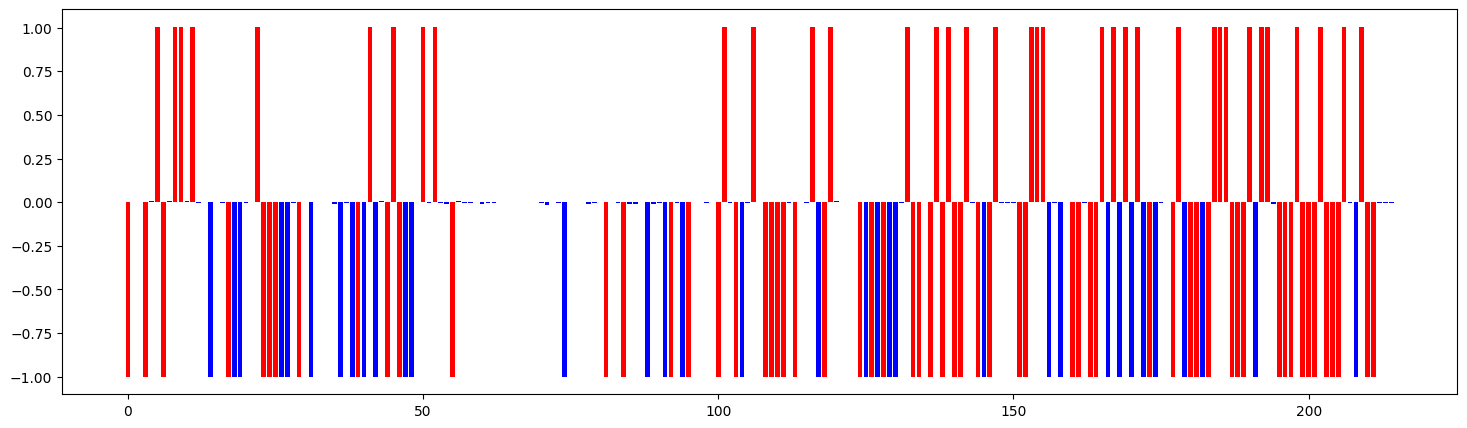

In [126]:
fig, ax = plt.subplots(figsize=(18, 5))
test_labels_without_absent = {k: v for k, v in test_labels.items() if v != -1}
train_labels_inter_test = {k: train_labels[k] for k, v in test_labels_without_absent.items()}
train_labels_outer_test = {k: v for k, v in train_labels.items() if k not in test_labels_without_absent.keys()}

diff = np.array(list(train_labels.values())) - np.array(list(test_labels.values()))
idx_absent_from_test = np.array([k for k, v in test_labels.items() if v == -1]).astype(int)
colors = ['red' if k in idx_absent_from_test else 'blue' for k in np.array(list(train_labels.keys())).astype(int)]
for k, v in enumerate(diff):
    diff[k] = -1 if k in idx_absent_from_test else v
ax.bar(np.array(list(train_labels.keys())).astype(int), diff, color=colors)
plt.plot()